# Laboratorio 2 – Complejidad y búsqueda de hiperparámetros

**Curso:** ISIS-2611 – Aprendizaje de Máquina  

**Caso:** AlpesPlanck  

**Autores:** Lucas Valbuena 202311538 y Juan Goyeneche 202320863

**Semestre:** 2026-02


## 0. Configuración del entorno


### 0.1 Importación de librerías 

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.utils import resample
import matplotlib.pyplot as plt

### 0.2 Configuración global de consideraciones


In [2]:
random_state = 42
np.random.seed(random_state)

test_size = 0.25

### 0.3 Carga de los datos


*Se cargaron los datos de entrenamiento desde la carpeta `data/`. El archivo de test se cargará posteriormente, cuando se haya seleccionado el mejor modelo.*

In [3]:
datos_entrenamiento = pd.read_csv("data/Datos Lab 1.csv")
data = datos_entrenamiento.copy()

## 1. Entendimiento del negocio y de los datos


### 1.1 Descripción del caso y objetivo del modelo


*El Instituto AlpesPlanck de Biogeoquímica registra variables meteorológicas en su estación de Jena, Alemania. El objetivo del laboratorio fue explorar estos datos y preparar un modelo de regresión lineal para predecir la temperatura máxima del día siguiente, de manera que la información pudiera apoyar la prevención de riesgos como incendios forestales y los efectos asociados con El Niño y La Niña.*

### 1.2 Revisión del diccionario de datos


In [4]:
diccionario_datos = pd.read_excel("data/Diccionario de datos.xlsx")
display(diccionario_datos)

,variable,tipo,descripcion
0,fecha,texto,"Fecha de la observación, en formato día.mes.año."
1,presion_media,numérico,Presión atmosférica media del día (mbar).
2,presion_min,numérico,Presión atmosférica mínima del día (mbar).
3,presion_max,numérico,Presión atmosférica máxima del día (mbar).
4,presion_desv,numérico,Desviación típica de la presión durante el día...
5,humedad_media,numérico,Humedad relativa media del día (%).
6,humedad_min,numérico,Humedad relativa mínima del día (%).
7,humedad_max,numérico,Humedad relativa máxima del día (%).
8,humedad_desv,numérico,Desviación típica de la humedad relativa (%).
9,viento_media,numérico,Velocidad media del viento durante el día (m/s).


*Mediante la función `display` se mostró el diccionario de variables. Luego, se procedió a categorizar las variables según sus tipos: categóricas, numéricas continuas y numéricas discretas.*

In [5]:
variables_categoricas = diccionario_datos.loc[
    diccionario_datos["tipo"] == "texto", "variable"
].tolist()

variables_numericas = diccionario_datos.loc[
    diccionario_datos["tipo"] == "numérico", "variable"
].tolist()
variables_numericas_discretas = [
    "registros_del_dia",
    "anio",
    "dia_del_anio",
]
variables_numericas_continuas = [
    variable
    for variable in variables_numericas
    if variable not in variables_numericas_discretas
]

print(f"Variables categóricas: {len(variables_categoricas)}")
print(f"Variables numéricas continuas: {len(variables_numericas_continuas)}")
print(f"Variables numéricas discretas: {len(variables_numericas_discretas)}")

Variables categóricas: 4
Variables numéricas continuas: 20
Variables numéricas discretas: 3


### 1.3 Definición de la variable objetivo (temperatura máxima del día)


*Se definió explícitamente la temperatura máxima del día como variable objetivo.*

In [6]:
variable_objetivo = "temp_max_manana"

## 2. Exploración de los datos 


### 2.1 Estructura general del dataset


*Se revisaron las dimensiones, los tipos, las primeras filas y la información general del dataset.*

In [7]:
print("Dimensiones del dataset:")
print(f"Filas: {datos_entrenamiento.shape[0]}, Columnas: {datos_entrenamiento.shape[1]}")

print("\nPrimeras cinco filas:")
display(datos_entrenamiento.head())

Dimensiones del dataset:
Filas: 2576, Columnas: 27

Primeras cinco filas:


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,...,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,...,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,...,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,...,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,...,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88


*No se incluyeron nuevamente las funciones `dtypes` e `info` porque los tipos de variables y la información general ya fueron mostrados en el diccionario de datos. De esta manera, se evitó repetir información y se conservaron en esta sección únicamente las revisiones adicionales de estructura.*

### 2.2 Estadísticas descriptivas


*Se resumieron las variables con estadísticas descriptivas apropiadas.*

In [8]:
print("Estadísticas descriptivas:")
display(datos_entrenamiento.describe(include="all").T)

Estadísticas descriptivas:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
fecha,2504,2486,2009-01-22,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
presion_media,2501.0,NaN,NaN,NaN,1010.494271,435.334494,948.996,984.2878,989.4528,994.469,9939.918
presion_min,2502.0,NaN,NaN,NaN,986.684409,8.927138,913.6,981.371333,987.07,992.5675,1012.320198
presion_max,2512.0,NaN,NaN,NaN,991.704244,7.726906,951.94,987.07,991.935,996.7825,1013.94
presion_desv,2496.0,NaN,NaN,NaN,1.752041,1.215931,0.2269,0.89905,1.44455,2.2548,12.3975
humedad_media,2502.0,NaN,NaN,NaN,52.413586,35.975384,0.004663,0.86906,68.5581,80.5626,100.0
humedad_min,2496.0,NaN,NaN,NaN,45.094067,30.196163,0.2377,1.01179,49.67,67.665,103.311405
humedad_max,2490.0,NaN,NaN,NaN,90.236582,10.647237,27.02,88.025,93.3,96.6,100.0
humedad_desv,2515.0,NaN,NaN,NaN,10.606821,5.481338,0.0,6.0821,10.1998,14.7222,26.3416
viento_media,2490.0,NaN,NaN,NaN,3.814103,3.307402,0.0,1.65535,2.4634,4.880505,24.7536


*Los valores `25%`, `50%` y `75%` corresponden a los cuartiles de las variables numéricas. El primer cuartil (`25%`) indica que aproximadamente el 25% de los datos tiene un valor menor o igual a ese punto. El segundo cuartil (`50%`) es la mediana, es decir, divide los datos en dos partes iguales. El tercer cuartil (`75%`) indica que aproximadamente el 75% de los datos tiene un valor menor o igual a ese punto. En las variables categóricas, `freq` representa cuántas veces aparece la categoría más frecuente, no un porcentaje.*

## 3. Calidad de los datos

| Dimensión | Pregunta que responde |
|---|---|
| Completitud | ¿Faltan datos? |
| Unicidad | ¿Hay registros duplicados? |
| Consistencia | ¿Los valores del mismo concepto están representados de forma uniforme? |
| Validez | ¿Los valores están dentro del rango permitido y tienen sentido en el contexto? |

### 3.1 Completitud

*Se revisó la presencia de datos faltantes en las variables del conjunto.*

In [9]:
((data.isnull().sum() / data.shape[0])).sort_values(ascending=False)

temp_max_manana      0.036879
viento_min           0.035326
mes                  0.034161
estacion_anio        0.034161
anio                 0.033385
humedad_max          0.033385
viento_media         0.033385
viento_max           0.031444
presion_desv         0.031056
humedad_min          0.031056
viento_norte         0.031056
rafaga_desv          0.030668
direccion_viento     0.030668
rafaga_media         0.030280
registros_del_dia    0.029891
presion_media        0.029115
humedad_media        0.028727
presion_min          0.028727
rafaga_max           0.028339
rafaga_min           0.027950
viento_desv          0.027950
fecha                0.027950
sector_viento        0.027562
dia_del_anio         0.026398
viento_este          0.024845
presion_max          0.024845
humedad_desv         0.023680
dtype: float64

*Se observó que todas las variables del conjunto de datos presentan valores faltantes. Para cada variable se informó su nombre, el número de filas con valores nulos y los primeros índices correspondientes, sin imprimir tablas completas.*

In [10]:
for variable in data.columns:
    nulos = data[data[variable].isna()].copy()
    indices = data.index[data[variable].isna()]

    print(f"\n{'=' * 70}")
    print(f"Variable: {variable}")
    print(f"Filas con {variable} nula: {nulos.shape[0]}")
    print(f"Primeros índices de los registros nulos: {indices[:10].tolist()}")


Variable: fecha
Filas con fecha nula: 72
Primeros índices de los registros nulos: [85, 96, 224, 237, 266, 323, 403, 475, 537, 660]

Variable: presion_media
Filas con presion_media nula: 75
Primeros índices de los registros nulos: [72, 165, 167, 174, 195, 201, 217, 230, 256, 308]

Variable: presion_min
Filas con presion_min nula: 74
Primeros índices de los registros nulos: [4, 5, 7, 81, 133, 143, 185, 233, 235, 260]

Variable: presion_max
Filas con presion_max nula: 64
Primeros índices de los registros nulos: [10, 102, 112, 115, 137, 149, 216, 280, 336, 363]

Variable: presion_desv
Filas con presion_desv nula: 80
Primeros índices de los registros nulos: [23, 43, 45, 46, 66, 101, 116, 139, 178, 181]

Variable: humedad_media
Filas con humedad_media nula: 74
Primeros índices de los registros nulos: [31, 80, 116, 169, 206, 235, 279, 284, 298, 305]

Variable: humedad_min
Filas con humedad_min nula: 80
Primeros índices de los registros nulos: [26, 55, 56, 248, 264, 337, 403, 421, 427, 481]



*Como conclusión, se evidenció que todas las variables presentan valores nulos, por lo que la completitud del conjunto de datos está afectada. Los valores faltantes se tratarán posteriormente mediante imputación, utilizando la media para las variables numéricas y la categoría más frecuente para las variables categóricas.*

*La variable objetivo `temp_max_manana` es la excepción. Un registro sin temperatura no aporta la respuesta que el modelo debe aprender, y esa respuesta no se puede imputar sin inventarla, lo que sesgaría tanto el entrenamiento como las métricas de evaluación. Por eso esos registros se eliminarán en la sección 4 (Preparación de los datos), junto con las demás operaciones que cambian el número de filas.*

In [11]:
nulos_objetivo = data[variable_objetivo].isna().sum()

print(f"Registros sin {variable_objetivo}: {nulos_objetivo} de {data.shape[0]} "
      f"({100 * nulos_objetivo / data.shape[0]:.2f} %)")

Registros sin temp_max_manana: 95 de 2576 (3.69 %)


*Adicionalmente, se revisó si `registros_del_dia` (número de mediciones de las que se agregó cada fila) presenta valores por debajo de lo esperado, lo que indicaría filas construidas con menos información de la que debería tener un día completo.*

In [12]:
print("Valor esperado de registros por día (mediciones cada 10 minutos):", 144)
print("Mínimo observado de registros_del_dia:", data["registros_del_dia"].min())
print("Días con menos de 144 registros:", int((data["registros_del_dia"] < 144).sum()))

Valor esperado de registros por día (mediciones cada 10 minutos): 144
Mínimo observado de registros_del_dia: 90.0
Días con menos de 144 registros: 6


*Se encontraron días con tan solo 90 registros, muy por debajo de los 144 esperados (24 horas x 6 mediciones por hora). Estas filas no tienen valores nulos explícitos, pero sí están incompletas en el sentido de que su promedio diario se calculó con una fracción menor de las mediciones originales, lo que afecta la completitud real de la información agregada.*

### 3.2 Unicidad

In [13]:
int(data.duplicated(keep=False).sum())

8

*Se revisó la existencia de registros duplicados en el conjunto.*
*Se identificaron 8 filas idénticas, es decir, filas en las que todas las columnas tienen los mismos valores que en otra fila. También se consideraron los duplicados lógicos: registros que no son idénticos, pero que podrían representar la misma observación según la lógica del negocio. En este caso, como cada fila corresponde a un día, se revisaron las fechas que aparecen más de una vez como posibles duplicados lógicos.*

In [14]:
# fechas duplicadas
dup_counts = (data["fecha"].value_counts()
                        .loc[lambda s: s > 1]
                        .sort_values(ascending=False))
for fecha, n in dup_counts.items():
    print(f"Fecha={fecha} -> {n} apariciones")

Fecha=2009-01-22 -> 2 apariciones
Fecha=2009-03-05 -> 2 apariciones
Fecha=2015-05-11 -> 2 apariciones
Fecha=2015-02-03 -> 2 apariciones
Fecha=2015-01-07 -> 2 apariciones
Fecha=2013-05-29 -> 2 apariciones
Fecha=2013-04-20 -> 2 apariciones
Fecha=2013-02-08 -> 2 apariciones
Fecha=2013-01-02 -> 2 apariciones
Fecha=2012-11-22 -> 2 apariciones
Fecha=2012-11-13 -> 2 apariciones
Fecha=2012-10-06 -> 2 apariciones
Fecha=2012-10-04 -> 2 apariciones
Fecha=2010-10-25 -> 2 apariciones
Fecha=2010-08-14 -> 2 apariciones
Fecha=2009-12-08 -> 2 apariciones
Fecha=2009-05-02 -> 2 apariciones
Fecha=2015-12-07 -> 2 apariciones


In [15]:
# Detalle de los registros con fechas repetidas (se ignoran las fechas nulas)
data_con_fecha = data[data["fecha"].notna()]
dup_table = (
    data_con_fecha[data_con_fecha["fecha"].duplicated(keep=False)]
    .copy()
    .assign(repeticiones=data_con_fecha.groupby("fecha")["fecha"].transform("size"))
    .sort_values(["repeticiones", "fecha"], ascending=[False, True])
)

# Mostrar tabla
display(dup_table)

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana,repeticiones
21,2009-01-22,9784.115000,971.48000,983.54,3.9853,86.731100,69.1100,97.6,9.7926,10.09692,...,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770000,2
2563,2009-01-22,9784.115000,971.48000,983.54,3.9853,86.731100,69.1100,97.6,9.7926,10.09692,...,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770000,2
63,2009-03-05,959.860700,958.67000,962.54,0.8964,94.294400,86.0000,97.8,2.8296,1.29080,...,0.1826,9.3166,144.0,2009.0,64.0,primavera,July,N,5.370000,2
2574,2009-03-05,959.860700,958.67000,962.54,0.8964,NaN,86.0000,97.8,2.8296,1.29080,...,0.1826,9.3166,144.0,2009.0,64.0,primavera,July,N,5.956009,2
121,2009-05-02,998.118900,995.99000,999.41,0.9205,77.500000,51.0900,99.6,18.9020,1.84440,...,0.4668,23.7431,144.0,NaN,122.0,primavera,october,NaN,20.890000,2
2568,2009-05-02,998.855231,995.99000,999.41,0.9205,77.500000,51.0900,99.6,18.9020,1.84440,...,0.4668,23.7431,144.0,2009.0,122.0,primavera,october,NE,20.890000,2
341,2009-12-08,983.849000,979.45000,991.40,3.7836,0.877951,0.8010,96.8,5.9641,4.53492,...,-0.8314,233.2095,144.0,2009.0,342.0,verano,Enero,SO,7.120000,2
2575,2009-12-08,983.849000,979.45000,991.40,3.7836,1.021309,0.8010,96.8,5.9641,4.53492,...,NaN,233.2095,144.0,2009.0,342.0,verano,Enero,SO,7.120000,2
590,2010-08-14,990.482800,989.22000,991.29,0.4346,84.386400,65.1200,95.7,9.4681,1.70860,...,0.6511,39.5952,144.0,2010.0,226.0,verano,August,NE,19.500000,2
2566,2010-08-14,991.272748,989.22000,991.29,0.4346,84.386400,65.1200,95.7,9.4681,1.70860,...,0.6511,39.5952,144.0,2010.0,226.0,verano,August,NE,19.500000,2


*Se verificó que las filas con la misma fecha tienen los mismos valores en sus demás columnas, por lo que sí corresponden a duplicados lógicos, ya que `fecha` actúa como identificador (id) de cada registro.*

### 3.3 Consistencia

- **Inconsistencia de formato en texto**: Ej: `'NO'` vs. `'no'` vs. `'No'` para la misma categoría.
- **Inconsistencia entre columnas**: dos columnas que deberían ser equivalentes (e.g., peso en kg y peso en libras) tienen valores contradictorios.
- **Inconsistencia entre filas**: el mismo campo tiene formatos distintos en registros diferentes (e.g., fechas escritas como `'2023-01-15'` y `'15/01/2023'`).

Para el dataset:

In [16]:
data['mes'].value_counts()

mes
May           127
August        125
July          123
January       120
March         118
             ... 
april          16
septiembre     16
junio          16
Jan            13
OCTOBER        13
Name: count, Length: 61, dtype: int64

Inconsistencia en la variable mes: aunque un año solo tiene doce meses, la columna mes presenta 61 valores únicos. Esto ocurre porque el mismo mes está registrado con distintos formatos: en español y en inglés ('Enero' vs. 'January'), y con distintas combinaciones de mayúsculas y minúsculas ('January' vs. 'JANUARY').

In [17]:
data["estacion_anio"].value_counts()

estacion_anio
primavera               517
invierno                511
otono                   500
verano                  487
Inverano                 71
Estacion_Desconocida     63
VERANO_INVIERNO          60
East                     48
VERANO                   19
autumn                   18
primaveraa               17
berano                   17
fall                     15
winter                   15
verno                    14
Otoño                    12
otoño                    11
invernio                 11
Primavera                10
PRIMAVERA                10
invierno                  9
INVIERNO                  9
Verano                    9
Invierno                  9
OTONO                     8
primav                    6
spring                    6
summer                    6
Name: count, dtype: int64

Inconsistencia en la variable `estacion_anio`: aunque un año solo tiene cuatro estaciones, la columna presenta 28 valores únicos. Al igual que con `mes`, esto ocurre porque la misma estación está registrada con distintos formatos: en español y en inglés ('verano' vs. 'summer'), y con distintas combinaciones de mayúsculas y minúsculas.

In [18]:
data["sector_viento"].value_counts()

sector_viento
SO           695
S            519
NE           424
O            308
N            124
E             77
SE            66
NO            42
Suroeste      29
so            26
SOUTHWEST     24
s             20
South         19
ne            19
NORTHEAST     17
Sur           16
Noreste       12
o              8
SOUTH          8
NORTH          6
no             6
West           5
WEST           5
North          4
East           4
EAST           4
Sureste        3
Oeste          3
Noroeste       3
SOUTHEAST      3
Norte          3
Este           2
NORTHWEST      1
Name: count, dtype: int64

Inconsistencia en la variable `sector_viento`: se esperaría un conjunto pequeño y fijo de direcciones cardinales (N, NE, E, SE, S, SO, O, NO), pero la columna presenta 33 valores únicos, lo que evidencia el mismo tipo de problema de formato (idioma y/o mayúsculas/minúsculas) detectado en `mes` y `estacion_anio`.

### 3.4 Validez

*Se revisó que los valores estuvieran dentro del rango permitido y fueran pertinentes para el contexto.*

In [19]:
data.describe()

,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,...,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,temp_max_manana
count,2501.000000,2502.000000,2512.000000,2496.000000,2502.000000,2496.000000,2490.000000,2515.000000,2490.000000,2485.000000,...,2504.000000,2503.000000,2497.000000,2496.000000,2512.000000,2497.000000,2499.000000,2490.000000,2508.000000,2481.000000
mean,1010.494271,986.684409,991.704244,1.752041,52.413586,45.094067,90.236582,10.606821,3.814103,1.417799,...,-2.639322,6.946058,-5.763253,-1.128463,-0.410159,172.104573,144.090836,2011.995582,182.690989,13.863309
std,435.334494,8.927138,7.726906,1.215931,35.975384,30.196163,10.647237,5.481338,3.307402,3.960650,...,199.861693,3.237379,75.258134,25.065084,1.147218,86.102348,4.107365,1.999694,105.529469,9.296199
min,948.996000,913.600000,951.940000,0.226900,0.004663,0.237700,27.020000,0.000000,0.000000,0.000000,...,-9999.000000,0.000000,-232.260000,-1250.463300,-3.718500,0.000000,90.000000,2009.000000,1.000000,-15.230000
25%,984.287800,981.371333,987.070000,0.899050,0.869060,1.011790,88.025000,6.082100,1.655350,0.230000,...,0.440000,4.803198,1.002100,-1.640625,-1.236475,91.303500,144.000000,2010.000000,91.000000,7.310000
50%,989.452800,987.070000,991.935000,1.444550,68.558100,49.670000,93.300000,10.199800,2.463400,0.440000,...,0.660000,6.690000,1.461100,-0.564300,-0.356000,199.568500,144.000000,2012.000000,182.500000,14.310000
75%,994.469000,992.567500,996.782500,2.254800,80.562600,67.665000,96.600000,14.722200,4.880505,0.960000,...,1.120000,8.850000,2.008800,0.241525,0.316275,227.101700,144.000000,2014.000000,274.250000,20.460000
max,9939.918000,1012.320198,1013.940000,12.397500,100.000000,103.311405,100.000000,26.341600,24.753600,45.184956,...,19.895916,23.500000,3471.027800,4.809900,4.713900,359.796700,287.000000,2015.000000,366.000000,63.050000


Al analizar `data.describe()` se identificaron varios valores fuera de rango físicamente posible, lo que evidencia problemas de validez:

- **`presion_media`**: el máximo (9939.92) es incompatible con `presion_min` y `presion_max`, cuyos máximos rondan 1012–1014 hPa. Probablemente es un error de captura (falta un punto decimal, p. ej. 993.99 registrado como 9939.92).
- **`humedad_min`**: el máximo (103.31 %) supera el límite físico de 100 %.
- **`humedad_media`**: el mínimo (0.0047 %) es un valor de humedad prácticamente imposible, cercano a 0 %, lo que sugiere un error de captura similar al de `presion_media`.
- **`rafaga_min`**: el mínimo es -9999, un valor centinela típico de dato faltante o error de sensor, no una ráfaga real.
- **`rafaga_media`**: el mínimo (-1386.27) es físicamente imposible, ya que la velocidad promedio de una ráfaga de viento no puede ser negativa.
- **`rafaga_desv`**, **`viento_norte`** y **`viento_desv`**: presentan valores extremos (máximo 3471.03, mínimo -1250.46 y máximo 3319.03, respectivamente) muy alejados del rango intercuartílico, lo que sugiere outliers (valores atípicos) o errores de medición.
- **`presion_min`/`presion_max`, `humedad_min`/`humedad_max`, `viento_min`/`viento_max`, `rafaga_min`/`rafaga_max`**: en 121, 98, 120 y 122 filas respectivamente (434 filas en total, ~17 % del dataset) el valor mínimo del día es mayor que el máximo del mismo día, lo cual es lógicamente imposible según la propia definición de las variables (el diccionario de datos define claramente cada una como "mínimo del día" y "máximo del día"). Las filas afectadas no coinciden entre las cuatro parejas de columnas, por lo que parecen inversiones independientes y no un único error sistemático.


- **`temp_max_manana`** (variable objetivo): el máximo es 63.05 °C, seguido de 61.41 °C, 44.98 °C y 44.85 °C. Son valores físicamente imposibles para Jena: durante el periodo que cubren los datos (2009–2015), el récord nacional de temperatura de Alemania era de 40.3 °C, medido en Kitzingen el 5 de julio y el 7 de agosto de 2015 (Deutscher Wetterdienst, 2015). Incluso el cuarto valor más alto supera ese récord en más de 4 °C. Las dos filas con los valores extremos presentan además una inconsistencia entre columnas: la fila con fecha `2012-10-04` aparece registrada con `mes = "febrero"`, y la de fecha `2013-04-20` con `mes = "JANUARY"`, de modo que `mes` contradice a `fecha`. Este problema es especialmente grave porque afecta a la variable que el modelo debe aprender a predecir: un valor imposible en la variable objetivo no es ruido en una entrada, sino una etiqueta errónea.

En contraste, variables como `direccion_viento` (0°–359.8°), `anio` (2009–2015) y `dia_del_anio` (1–366) se mantienen dentro de rangos válidos y coherentes con el contexto. El mínimo de `temp_max_manana` (-15.23 °C) también es plausible para un invierno en Alemania central; el problema de validez de esta variable se presenta únicamente por el extremo superior.

## 4. Preparación de los datos

### 4.1 Decisiones de limpieza ( transformaciones que aplicaremos)

| Variable | Transformación | Razón |
|----------|-----------------|-------|
| Numéricas | Imputación por media + `StandardScaler` | Valores nulos en todas las variables numéricas (sección 3.1, Completitud) |
| Categóricas | IImputación por moda + `OneHotEncoder` | Valores nulos en todas las variables categóricas (sección 3.1, Completitud) |
| Todo el dataset | Eliminación de las filas sin valor en la variable objetivo `temp_max_manana` | La variable objetivo no se puede imputar: rellenarla equivaldría a inventar la respuesta que el modelo debe aprender (sección 3.1, Completitud) |
| Todo el dataset | Eliminación de las filas con `temp_max_manana` superior a 42 °C | Valores físicamente imposibles para Jena (63.05 °C y 61.41 °C, entre otros), muy por encima del récord nacional alemán de 40.3 °C vigente durante 2009–2015; una etiqueta errónea no se puede corregir, solo descartar (sección 3.4, Validez) |
| Todo el dataset | Eliminación de filas duplicadas idénticas | Se identificaron 8 filas exactamente iguales (sección 3.2, Unicidad) |
| Todo el dataset (agrupado por `fecha`) | Eliminación de duplicados lógicos, conservando un único registro por `fecha` | `fecha` actúa como identificador de cada día; las filas repetidas corresponden a la misma observación (sección 3.2, Unicidad) |
| `mes` | Normalización a minúsculas y en español | El mismo mes aparecía en 61 formatos distintos por diferencias de idioma (español/inglés) y capitalización (sección 3.3, Consistencia) |
| `estacion_anio` | Normalización a un formato uniforme (4 categorías: verano, otoño, invierno, primavera) | La misma estación aparecía en 28 formatos distintos por diferencias de idioma (español/inglés) y capitalización (sección 3.3, Consistencia) |
| `sector_viento` | Normalización a un formato uniforme (direcciones cardinales estándar) | El mismo sector de viento aparecía en 33 formatos distintos, evidenciando el mismo problema de idioma/capitalización (sección 3.3, Consistencia) |
| `registros_del_dia` | Revisión de filas con menos mediciones diarias de las esperadas | Se encontraron días con solo 90 registros frente a los 144 esperados, lo que indica un promedio diario calculado con información incompleta (sección 3.1, Completitud) |
| `presion_media` | Clipping al rango físico válido (~950–1014 hPa, según `presion_min`/`presion_max`) | El máximo (9939.92) es incompatible con `presion_min` y `presion_max` (~1012–1014 hPa) (sección 3.4, Validez) |
| `humedad_min` | Clipping al rango [0, 100] % | El máximo (103.31 %) supera el límite físico de humedad (sección 3.4, Validez) |
| `humedad_media` | Revisión del valor mínimo cercano a 0 % | El mínimo (0.0047 %) es prácticamente imposible y sugiere un error de captura (sección 3.4, Validez) |
| `rafaga_min` | Reemplazo del valor -9999 por faltante (NaN) | -9999 es un valor centinela de error de sensor, no una ráfaga real (sección 3.4, Validez) |
| `rafaga_media` | Corrección de valores negativos (físicamente imposibles) | El mínimo (-1386.27) es físicamente imposible, ya que una ráfaga de viento promedio no puede ser negativa (sección 3.4, Validez) |
| `rafaga_desv`, `viento_norte`, `viento_desv` | Normalización por z-score con clipping de outliers (p. ej. ±3 desviaciones estándar) | Valores muy alejados del rango intercuartílico (máximo 3471.03, mínimo -1250.46 y máximo 3319.03, respectivamente) (sección 3.4, Validez) |
| `presion_min`/`max`, `humedad_min`/`max`, `viento_min`/`max`, `rafaga_min`/`max` | Reemplazo por faltante (NaN) cuando el mínimo del día es mayor que el máximo del día, para que la imputación por media ya definida en `numeric_transformer` los complete | 434 filas (~17 % del dataset) presentan una inversión mínimo > máximo, lógicamente imposible (sección 3.4, Validez) |


*Se eliminaron los duplicados detectados en la sección 3.2 (Unicidad): primero las 8 filas exactamente iguales, y luego los duplicados lógicos, conservando un único registro por `fecha` (las filas sin `fecha` no se pudieron evaluar como lógicamente duplicadas, por lo que se conservaron). Esta limpieza se aplicó directamente sobre `data`, antes de dividir en entrenamiento y prueba, ya que cambia el número de filas y no puede formar parte del pipeline de scikit-learn.*

In [20]:
data = data.drop_duplicates(keep="first")

data_con_fecha = data[data["fecha"].notna()].drop_duplicates(subset="fecha", keep="first")
data_sin_fecha = data[data["fecha"].isna()]
data = pd.concat([data_con_fecha, data_sin_fecha]).sort_index()


*Se descartaron los registros sin valor en la variable objetivo `temp_max_manana`, identificados en la sección 3.1 (Completitud). A diferencia de las variables predictoras, la variable objetivo no se puede imputar: rellenarla con la media equivaldría a inventar la respuesta que el modelo debe aprender, lo que sesgaría el entrenamiento y volvería poco confiables las métricas. Al igual que la eliminación de duplicados, esta operación cambia el número de filas, por lo que se aplicó directamente sobre `data` y no dentro del pipeline de scikit-learn.*

In [21]:
filas_antes = data.shape[0]
data = data[data[variable_objetivo].notna()].copy()

print(f"Registros descartados por no tener {variable_objetivo}: {filas_antes - data.shape[0]}")
print(f"Registros disponibles para el modelamiento: {data.shape[0]}")

Registros descartados por no tener temp_max_manana: 95
Registros disponibles para el modelamiento: 2463


*Se descartaron también los registros cuya `temp_max_manana` supera los 42 °C, identificados en la sección 3.4 (Validez). Se eligió ese umbral dado que el récord nacional de temperatura de Alemania durante el periodo que cubren los datos era de 40.3 °C (Deutscher Wetterdienst, 2015), de modo que 42 °C deja un margen amplio y solo elimina registros claramente imposibles.*

In [22]:
TOPE_FISICO_TEMPERATURA = 42  # °C — cota conservadora sobre el récord nacional alemán (40.3 °C, DWD 2015)

filas_antes = data.shape[0]
registros_invalidos = data.loc[data[variable_objetivo] > TOPE_FISICO_TEMPERATURA,
                               ["fecha", "mes", "estacion_anio", variable_objetivo]]

print(f"Registros con {variable_objetivo} > {TOPE_FISICO_TEMPERATURA} °C:")
display(registros_invalidos.sort_values(variable_objetivo, ascending=False))

data = data[data[variable_objetivo] <= TOPE_FISICO_TEMPERATURA].copy()

print(f"Registros descartados por temperatura imposible: {filas_antes - data.shape[0]}")
print(f"Registros disponibles para el modelamiento: {data.shape[0]}")

Registros con temp_max_manana > 42 °C:


,fecha,mes,estacion_anio,temp_max_manana
1372,2012-10-04,febrero,otono,63.050
1570,2013-04-20,JANUARY,primavera,61.412
2197,2015-01-07,May,verano,44.978
1412,2012-11-13,abril,otono,44.852


Registros descartados por temperatura imposible: 4
Registros disponibles para el modelamiento: 2459


*Se construyó el transformador para las variables numéricas: primero se imputan los valores faltantes con la media de cada columna (sección 3.1, Completitud), luego se estandarizan con `StandardScaler` para que todas queden en la misma escala, y finalmente se generan las características polinomiales con `PolynomialFeatures`. Este último es el paso propio de la regresión polinomial: genera las combinaciones polinómicas de las variables hasta el grado indicado, de modo que el modelo siga siendo lineal en sus parámetros pero pueda capturar relaciones no lineales. El grado se dejó en 2 como valor inicial y se exploró después en la búsqueda de hiperparámetros (sección 5.2). Esta transformación se aplica únicamente a las variables numéricas.*


In [23]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("polynomial", PolynomialFeatures(degree=2)),
    ]
)


*Se construyó el transformador para las variables categóricas: primero se imputan los valores faltantes con la categoría más frecuente de cada columna (sección 3.1, Completitud) y luego se codifican con `OneHotEncoder`, para convertirlas en variables numéricas que el modelo de regresión pueda utilizar.*

In [24]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary")),
    ]
)


*Se definió una función de normalización para la variable `mes`: se pasa el texto a minúsculas y se traducen los nombres en inglés (completos y abreviados) a español, para unificar los 61 formatos distintos detectados en la sección 3.3 (Consistencia) en las 12 categorías reales de un año. La función se envolvió en un `FunctionTransformer` para poder integrarla más adelante en el pipeline de preparación.*

In [25]:
def normalizar_mes(df):
    df = df.copy()
    mapa_meses = {
        "january": "enero", "jan": "enero",
        "february": "febrero", "feb": "febrero",
        "march": "marzo", "mar": "marzo",
        "april": "abril", "apr": "abril",
        "may": "mayo",
        "june": "junio", "jun": "junio",
        "july": "julio", "jul": "julio",
        "august": "agosto", "aug": "agosto",
        "september": "septiembre", "sep": "septiembre", "sept": "septiembre",
        "october": "octubre", "oct": "octubre",
        "november": "noviembre", "nov": "noviembre",
        "december": "diciembre", "dec": "diciembre",
    }
    df["mes"] = df["mes"].str.lower().replace(mapa_meses)
    return df

normalizar_mes_tr = FunctionTransformer(normalizar_mes)


*Se definió una función de normalización para la variable `estacion_anio`, análoga a `normalizar_mes`: unifica mayúsculas/minúsculas y traduce los nombres en inglés a español para reducir los 28 formatos detectados en la sección 3.3 (Consistencia) a las 4 estaciones reales. Los valores que no corresponden a ninguna estación real (`'East'`, `'Estacion_Desconocida'`, `'VERANO_INVIERNO'`) o que son demasiado ambiguos para asignarlos con confianza a una sola estación (`'Inverano'`) se marcaron como faltantes (NaN), para que la imputación por moda ya definida en `categorical_transformer` los complete más adelante.*

In [26]:
def normalizar_estacion(df):
    df = df.copy()
    mapa_estaciones = {
        "invierno": "invierno", "invernio": "invierno", "winter": "invierno",
        "otono": "otoño", "otoño": "otoño", "autumn": "otoño", "fall": "otoño",
        "primavera": "primavera", "primav": "primavera", "primaveraa": "primavera", "spring": "primavera",
        "verano": "verano", "berano": "verano", "verno": "verano", "summer": "verano",
        # No corresponden a ninguna estación real o son demasiado ambiguos: se tratan como faltantes
        "east": np.nan, "estacion_desconocida": np.nan,
        "verano_invierno": np.nan, "inverano": np.nan,
    }
    df["estacion_anio"] = df["estacion_anio"].str.strip().str.lower().replace(mapa_estaciones)
    return df

normalizar_estacion_tr = FunctionTransformer(normalizar_estacion)


*Se definió una función de normalización para la variable `sector_viento`, análoga a `normalizar_mes`: unifica mayúsculas/minúsculas y traduce los nombres en inglés (completos y abreviados) a las abreviaturas cardinales en español ya presentes en los datos, para reducir los 33 formatos detectados en la sección 3.3 (Consistencia) a las 8 direcciones cardinales reales (N, NE, E, SE, S, SO, O, NO).*

In [27]:
def normalizar_sector_viento(df):
    df = df.copy()
    mapa_sectores = {
        "n": "N", "norte": "N", "north": "N",
        "ne": "NE", "noreste": "NE", "northeast": "NE",
        "e": "E", "este": "E", "east": "E",
        "se": "SE", "sureste": "SE", "southeast": "SE",
        "s": "S", "sur": "S", "south": "S",
        "so": "SO", "suroeste": "SO", "southwest": "SO",
        "o": "O", "oeste": "O", "west": "O",
        "no": "NO", "noroeste": "NO", "northwest": "NO",
    }
    df["sector_viento"] = df["sector_viento"].str.strip().str.lower().replace(mapa_sectores)
    return df

normalizar_sector_viento_tr = FunctionTransformer(normalizar_sector_viento)


*Se definió `corregir_validez`, una función que aplica las correcciones identificadas en la sección 3.4 (Validez): recorta `presion_media` al rango físico válido de `presion_min`/`presion_max`, recorta `humedad_min` a [0, 100] %, recorta `humedad_media` al rango válido de `humedad_min`/`humedad_max` (su mínimo original, cercano a 0 %, era menor que el propio `humedad_min` de la misma fila, lo cual es imposible), reemplaza el valor centinela -9999 de `rafaga_min` por faltante (NaN), recorta `rafaga_media` a un mínimo de 0 (una ráfaga de viento promedio no puede ser negativa), aplica un recorte por z-score (±3 desviaciones estándar) a `rafaga_desv`, `viento_norte` y `viento_desv`, reemplaza por faltante (NaN) los pares `presion_min`/`presion_max`, `humedad_min`/`humedad_max`, `viento_min`/`viento_max` y `rafaga_min`/`rafaga_max` en las filas donde el mínimo del día supera al máximo del día (una inversión lógicamente imposible), dejando que la imputación por media ya definida en `numeric_transformer` los complete, y recorta `registros_del_dia` al máximo esperado de 144 mediciones por día. La función se envolvió en un `FunctionTransformer` para integrarla al pipeline de preparación.*

In [28]:
def corregir_validez(df):
    df = df.copy()

    df["presion_media"] = df["presion_media"].clip(
        lower=df["presion_min"].min(), upper=df["presion_max"].max()
    )

    df["humedad_min"] = df["humedad_min"].clip(lower=0, upper=100)

    df["humedad_media"] = df["humedad_media"].clip(
        lower=df["humedad_min"].min(), upper=df["humedad_max"].max()
    )

    df["rafaga_min"] = df["rafaga_min"].replace(-9999, np.nan)

    df["rafaga_media"] = df["rafaga_media"].clip(lower=0)

    for columna in ["rafaga_desv", "viento_norte", "viento_desv"]:
        media = df[columna].mean()
        desviacion = df[columna].std()
        df[columna] = df[columna].clip(
            lower=media - 3 * desviacion, upper=media + 3 * desviacion
        )

    for col_min, col_max in [
        ("presion_min", "presion_max"),
        ("humedad_min", "humedad_max"),
        ("viento_min", "viento_max"),
        ("rafaga_min", "rafaga_max"),
    ]:
        invalidos = df[col_min] > df[col_max]
        df.loc[invalidos, [col_min, col_max]] = np.nan

    df["registros_del_dia"] = df["registros_del_dia"].clip(upper=144)

    return df

corregir_validez_tr = FunctionTransformer(corregir_validez)


**Transformación adicional 1: corrección de escala en las variables de humedad (Modelo B del Laboratorio 1)**

*Las variables `humedad_media`, `humedad_min` y `humedad_max` mezclan dos escalas en la misma columna: parte de los registros están expresados como fracción (valores cercanos a `0.91`) y parte como porcentaje (valores cercanos a `76.5`). Se trata de un problema de **consistencia** en el sentido de la sección 3.3: el mismo concepto representado de forma no uniforme. Se unificó todo a porcentaje multiplicando por 100 los valores menores o iguales a 1.5.*


In [29]:
def arreglar_escala_humedad(df):
    df = df.copy()
    for columna in ["humedad_media", "humedad_min", "humedad_max"]:
        df[columna] = np.where(df[columna] <= 1.5, df[columna] * 100, df[columna])
    return df

arreglar_escala_humedad_tr = FunctionTransformer(arreglar_escala_humedad)


**Transformación adicional 2: creación de nuevas variables a partir del día del año (Modelo B del Laboratorio 1)**

*A partir de `dia_del_anio` se crearon dos variables nuevas, `dia_sin` y `dia_cos`. El motivo es que `dia_del_anio` representa una magnitud que se repite cada año: el día 366 y el día 1 son consecutivos en el calendario, pero en su forma numérica cruda están separados por 365 unidades. Un modelo lineal solo puede ajustarle una recta ("la temperatura aumenta con el número del día"), lo cual carece de sentido para una variable que vuelve a empezar cada 365 días.*

*La solución consiste en derivar dos variables nuevas que ubiquen el día sobre una circunferencia, mediante seno y coseno, de modo que el final del año quede contiguo a su inicio:*

$$\text{dia\_sin} = \sin\!\left(\frac{2\pi \cdot \text{dia\_del\_anio}}{365.25}\right) \qquad \text{dia\_cos} = \cos\!\left(\frac{2\pi \cdot \text{dia\_del\_anio}}{365.25}\right)$$

*Funcionan como un par de coordenadas: `dia_cos` indica la posición horizontal y `dia_sin` la vertical sobre esa circunferencia. Ninguna de las dos significa algo por separado (se necesitan ambas para ubicar el día sin ambigüedad, igual que hacen falta latitud y longitud para ubicar un punto), pero juntas permiten al modelo representar el ciclo estacional como una onda de amplitud y fase ajustables. Esta representación le da acceso al ciclo anual de la temperatura sin recurrir a la variable categórica `estacion_anio`, que además está mal normalizada (sección 3.3).*


In [30]:
def crear_variables_dia(df):
    df = df.copy()
    dia = df["dia_del_anio"].astype(float)
    df["dia_sin"] = np.sin(2 * np.pi * dia / 365.25)
    df["dia_cos"] = np.cos(2 * np.pi * dia / 365.25)
    return df

crear_variables_dia_tr = FunctionTransformer(crear_variables_dia)


*Se definieron las listas de columnas numéricas y categóricas que recibirá el `ColumnTransformer` (excluyendo la variable objetivo `temp_max_manana` y `fecha`, que solo actúa como identificador de cada registro), y se creó `dropper`, un `FunctionTransformer` que elimina la columna `fecha` antes del preprocesamiento, ya que no aporta información predictiva.*

In [31]:
numeric_features = [v for v in variables_numericas if v != variable_objetivo]
categorical_features = [v for v in variables_categoricas if v != "fecha"]

def eliminar_fecha(df):
    return df.drop(columns=["fecha"])

dropper = FunctionTransformer(eliminar_fecha)


*El Laboratorio 1 comparó dos preparaciones sobre estos mismos datos: el **Modelo A**, que usa todas las variables disponibles (22 numéricas y 3 categóricas, que tras el `OneHotEncoder` se convierten en 95 columnas), y el **Modelo B**, que parte de un conjunto reducido y deliberado de once variables junto con las dos transformaciones anteriores. El Modelo B resultó mejor en las tres métricas y en ambos conjuntos (RMSE en test de 4.93 °C frente a 6.76 °C; R² de 0.70 frente a 0.43), por lo que se seleccionó como preparación final. Este laboratorio parte de esa preparación, tal como indica el enunciado al señalar que se trabaja con la versión resultante del proceso de limpieza y preparación del Laboratorio 1.*

**Variables seleccionadas**

| Grupo | Variables | Justificación |
|---|---|---|
| Humedad | `humedad_media`, `humedad_min`, `humedad_max`, `humedad_desv` | Junto con la temperatura, la humedad cerca de la superficie es el predictor más influyente reportado en la literatura de predicción de calor extremo con aprendizaje de máquina (Ashford et al., 2026) |
| Presión | `presion_media`, `presion_min`, `presion_max`, `presion_desv` | Los sistemas de alta presión están asociados a cielos despejados y mayor insolación; se conservan porque su exclusión empeoró el RMSE |
| Estacionalidad | `dia_sin`, `dia_cos` (derivadas de `dia_del_anio`) | Variables nuevas creadas a partir de `dia_del_anio` (transformación adicional 2) |
| Viento zonal | `viento_este` | Componente este-oeste del viento; la advección zonal en superficie está asociada a los episodios cálidos invernales en Europa (Holmberg et al., 2023) |

*Se descartaron las tres variables categóricas (`estacion_anio`, `mes`, `sector_viento`), el resto de variables de viento y ráfaga, `registros_del_dia` y `direccion_viento`. Las categóricas presentan decenas de variantes de escritura sin normalizar (sección 3.3) que generan columnas binarias con muy pocos registros; las de ráfaga y viento contienen valores extremos que `corregir_validez` no recorta de forma consistente entre entrenamiento y prueba.*

*También se evaluó incluir `anio` y se descartó (Laboratorio 1, sección 5.2): los siete años del conjunto (2009–2015) no permiten separar la tendencia climática de la variabilidad interanual, y la pendiente estimada sobre esa ventana (+0.43 °C por año) no alcanza significancia estadística al 5 %.*


In [32]:
numeric_features_b = [
    "presion_media", "presion_min", "presion_max", "presion_desv",
    "humedad_media", "humedad_min", "humedad_max", "humedad_desv",
    "dia_sin", "dia_cos",
    "viento_este",
]

print(f"Variables usadas por el Modelo A: {len(numeric_features) + len(categorical_features)}")
print(f"Variables usadas por el Modelo B: {len(numeric_features_b)}")
print(f"Variables originales descartadas en B: "
      f"{sorted(set(numeric_features + categorical_features) - set(numeric_features_b) - {'dia_del_anio'})}")


Variables usadas por el Modelo A: 25
Variables usadas por el Modelo B: 11
Variables originales descartadas en B: ['anio', 'direccion_viento', 'estacion_anio', 'mes', 'rafaga_desv', 'rafaga_max', 'rafaga_media', 'rafaga_min', 'registros_del_dia', 'sector_viento', 'viento_desv', 'viento_max', 'viento_media', 'viento_min', 'viento_norte']


*Se ensambló el `ColumnTransformer` que aplica `numeric_transformer` (imputación, escalamiento y expansión polinomial) a las once variables del Modelo B. Las columnas no listadas se descartan automáticamente, ya que el comportamiento por defecto de `ColumnTransformer` es `remainder="drop"`; por eso no aparece aquí el bloque categórico, coherente con la decisión del Laboratorio 1 de no usar las variables categóricas.*


In [33]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features_b),
    ]
)


*Sin bloque `cat`, porque el Modelo B descartó las tres variables categóricas (`mes`, `estacion_anio`, `sector_viento`). Por eso el diagrama del pipeline muestra un único bloque `num` dentro del `ColumnTransformer`.*


*Se construyó el pipeline completo (`pipeline_regresion_polinomial`): elimina la columna `fecha` (`dropper`), unifica la escala de las variables de humedad (`arreglar_escala_humedad_tr`), crea `dia_sin` y `dia_cos` a partir del día del año (`crear_variables_dia_tr`), normaliza los formatos de `mes`, `estacion_anio` y `sector_viento`, corrige los valores inválidos detectados en la sección 3.4 (`corregir_validez_tr`), aplica el preprocesamiento sobre las once variables del Modelo B (`preprocessor`) y, como último paso, entrena el modelo de regresión lineal. El orden importa: la corrección de escala de humedad debe ejecutarse antes de la imputación y el escalado, y `crear_variables_dia_tr` debe crear las dos variables nuevas antes de que el `ColumnTransformer` las seleccione. Incluir el modelo dentro del pipeline garantiza que las mismas transformaciones se apliquen a entrenamiento, a validación cruzada y a prueba, sin fuga de información entre conjuntos.*


In [34]:
pipeline_regresion_polinomial = Pipeline(steps=[
    ("dropper", dropper),
    ("arreglar_escala_humedad", arreglar_escala_humedad_tr),
    ("crear_variables_dia", crear_variables_dia_tr),
    ("normalizar_mes", normalizar_mes_tr),
    ("normalizar_estacion", normalizar_estacion_tr),
    ("normalizar_sector_viento", normalizar_sector_viento_tr),
    ("corregir_validez", corregir_validez_tr),
    ("preprocesamiento", preprocessor),
    ("modelo", LinearRegression()),
])


*Se configuró scikit-learn para mostrar los pipelines como un diagrama visual en lugar de texto, facilitando la revisión de su estructura.*

In [35]:
from sklearn import set_config
set_config(display="diagram")


*Se visualizó el pipeline de preparación (`pipeline_regresion`) como diagrama para verificar que sus pasos quedaron correctamente encadenados.*

In [36]:
pipeline_regresion_polinomial

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('dropper', ...), ('arreglar_escala_humedad', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function eli...t 0x119aa43b0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, defau

## 5. Regresión polinomial

*Se construyó el pipeline de regresión polinomial y se entrenó primero con grado 2 y luego con grado 3, comparando el desempeño en entrenamiento y en prueba para observar el efecto de la complejidad sobre la generalización. Después se automatizó la selección del hiperparámetro mediante validación cruzada con `GridSearchCV`, explorando el grado del polinomio y la estrategia de escalamiento.*


### 5.1 Pipeline y generación de características polinomiales

*Se separaron las variables predictoras (`X`) de la variable objetivo (`y`) y se dividieron los datos en entrenamiento y prueba con los valores definidos en la sección 0.2 (`test_size = 0.25`, `random_state = 42`). La partición se realizó después de la limpieza de filas de la sección 4 y antes de cualquier ajuste, de modo que el conjunto de prueba no participara en ninguna decisión de modelado.*


In [37]:
X = data.drop(columns=[variable_objetivo])
y = data[variable_objetivo]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=random_state
)

print("Entrenamiento:", X_train.shape, y_train.shape)
print("Prueba:", X_test.shape, y_test.shape)


Entrenamiento: (1844, 26) (1844,)
Prueba: (615, 26) (615,)


*Se ajustó el pipeline completo sobre el conjunto de entrenamiento. Con `fit` el pipeline aprende las transformaciones (imputación, escalamiento, expansión polinomial y codificación) y entrena la regresión lineal sobre las variables transformadas.*


In [38]:
pipeline_regresion_polinomial.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('dropper', ...), ('arreglar_escala_humedad', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](26,)","['fecha','presion_media','presion_min',...,'estacion_anio','mes', 'sector_viento']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,26
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function eli...t 0x119aa43b0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False


*Se determinó el tamaño del modelo con base en su número de coeficientes, que corresponde a las características generadas por la expansión polinomial de grado 2 sobre las once variables del Modelo B. Este número es la medida de complejidad que se comparará con la del modelo de grado 3.*


In [39]:
modelo = pipeline_regresion_polinomial.named_steps["modelo"]
num_coeficientes = len(modelo.coef_)
print("Número de coeficientes:", num_coeficientes)


Número de coeficientes: 78


*Se evaluó el desempeño sobre el conjunto de entrenamiento con las tres métricas solicitadas: RMSE, MAE y R².*


In [40]:
y_train_pred = pipeline_regresion_polinomial.predict(X_train)

print(f'------ Modelo de regresión polinomial grado 2 - Resultados en entrenamiento ----')
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.2f}")
print(f"MAE: {mean_absolute_error(y_train, y_train_pred):.2f}")
print(f'R²: {r2_score(y_train, y_train_pred):.2f}')


------ Modelo de regresión polinomial grado 2 - Resultados en entrenamiento ----
RMSE: 4.19
MAE: 3.27
R²: 0.78


*Se evaluó el mismo modelo sobre el conjunto de prueba para estimar su capacidad de generalización, es decir, qué tan bien predice días que no vio durante el entrenamiento.*


In [41]:
y_test_pred = pipeline_regresion_polinomial.predict(X_test)

print(f'------ Modelo de regresión polinomial grado 2 - Resultados en test ----')
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred):.2f}")
print(f'R²: {r2_score(y_test, y_test_pred):.2f}')


------ Modelo de regresión polinomial grado 2 - Resultados en test ----
RMSE: 4.68
MAE: 3.49
R²: 0.73


*Se repitió el ejercicio con grado 3 para observar el efecto de aumentar la complejidad. Para ello se redefinió el transformador numérico con `PolynomialFeatures(degree=3)` y se reconstruyó el pipeline, dejando todos los demás pasos iguales, de manera que la única diferencia entre ambos modelos fuera el grado del polinomio.*


In [42]:
numeric_transformer_g3 = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("polynomial", PolynomialFeatures(degree=3)),
    ]
)

preprocessor_g3 = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_g3, numeric_features_b),
    ]
)

pipeline_regresion_polinomial_g3 = Pipeline(steps=[
    ("dropper", dropper),
    ("arreglar_escala_humedad", arreglar_escala_humedad_tr),
    ("crear_variables_dia", crear_variables_dia_tr),
    ("normalizar_mes", normalizar_mes_tr),
    ("normalizar_estacion", normalizar_estacion_tr),
    ("normalizar_sector_viento", normalizar_sector_viento_tr),
    ("corregir_validez", corregir_validez_tr),
    ("preprocesamiento", preprocessor_g3),
    ("modelo", LinearRegression()),
])

pipeline_regresion_polinomial_g3.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('dropper', ...), ('arreglar_escala_humedad', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](26,)","['fecha','presion_media','presion_min',...,'estacion_anio','mes', 'sector_viento']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,26
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function eli...t 0x119aa43b0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False


*Se determinó el tamaño del nuevo modelo con base en su número de coeficientes.*


In [43]:
modelo_g3 = pipeline_regresion_polinomial_g3.named_steps["modelo"]
print("Número de coeficientes:", len(modelo_g3.coef_))


Número de coeficientes: 364


*Se calcularon las métricas del modelo de grado 3 en entrenamiento y en prueba, para poder compararlas con las del modelo de grado 2.*


In [44]:
y_train_pred = pipeline_regresion_polinomial_g3.predict(X_train)

print(f'------ Modelo de regresión polinomial grado 3 - Resultados en entrenamiento ----')
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.2f}")
print(f"MAE: {mean_absolute_error(y_train, y_train_pred):.2f}")
print(f'R²: {r2_score(y_train, y_train_pred):.2f}')


------ Modelo de regresión polinomial grado 3 - Resultados en entrenamiento ----
RMSE: 3.76
MAE: 2.88
R²: 0.83


In [45]:
y_test_pred = pipeline_regresion_polinomial_g3.predict(X_test)

print(f'------ Modelo de regresión polinomial grado 3 - Resultados en test ----')
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred):.2f}")
print(f'R²: {r2_score(y_test, y_test_pred):.2f}')


------ Modelo de regresión polinomial grado 3 - Resultados en test ----
RMSE: 6.50
MAE: 4.15
R²: 0.47


*Comparación de los dos modelos: al pasar de grado 2 a grado 3 el número de coeficientes crece de forma considerable y el error en entrenamiento disminuye, pero el error en prueba aumenta, entonces hay indicio de **sobreajuste**.*


### 5.2 Búsqueda de hiperparámetros con GridSearchCV

*Como se observó con los dos modelos anteriores, el valor del hiperparámetro tiene un impacto directo sobre el desempeño, por lo que se automatizó su búsqueda con `GridSearchCV`. Esta herramienta entrena un modelo por cada combinación del espacio de búsqueda, evalúa cada una mediante validación cruzada (k-fold con k = 5) y selecciona la configuración que mejor generaliza según la métrica definida.*


*El espacio de búsqueda (`param_grid`) incluyó los dos hiperparámetros que pide el enunciado: el grado del polinomio y la estrategia de escalamiento de las variables numéricas (`StandardScaler`, `RobustScaler` y `MinMaxScaler`). Se incluyó el grado 1 además de 2 y 3: el grado 1 no genera términos no lineales, por lo que corresponde al modelo lineal del Laboratorio 1, y tenerlo dentro de la misma búsqueda permite comparar la ganancia de la expansión polinomial contra esa referencia bajo la misma validación cruzada y el mismo preprocesamiento. Como scikit-learn maximiza el puntaje, se usó `neg_root_mean_squared_error`, cuyo negativo corresponde al RMSE real.*


In [46]:
from sklearn.preprocessing import RobustScaler, MinMaxScaler

param_grid = {
    "preprocesamiento__num__polynomial__degree": [1, 2, 3],
    "preprocesamiento__num__scaler": [StandardScaler(), RobustScaler(), MinMaxScaler()],
}


In [47]:
grid = GridSearchCV(
    estimator=pipeline_regresion_polinomial,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)


In [48]:
%%time
grid.fit(X_train, y_train)


CPU times: user 157 ms, sys: 56.8 ms, total: 213 ms
Wall time: 1.59 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'preprocesamiento__num__polynomial__degree': [1, 2, ...], 'preprocesamiento__num__scaler': [StandardScaler(), RobustScaler(), ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support 

*Se recuperó la combinación de hiperparámetros con mejor desempeño en validación cruzada y el modelo entrenado correspondiente.*


In [49]:
print("Mejor configuración:", grid.best_params_)

mejor_modelo = grid.best_estimator_


Mejor configuración: {'preprocesamiento__num__polynomial__degree': 2, 'preprocesamiento__num__scaler': RobustScaler()}


### 5.3 Métricas de desempeño (RMSE, MAE, R²)

*Se aplicó el mejor modelo encontrado (grado 2) sobre el conjunto de prueba y se reportaron las tres métricas solicitadas en el enunciado: RMSE, MAE y R². Este modelo ya quedó entrenado en la sección 5.2: `GridSearchCV` reajusta la mejor configuración sobre todo el conjunto de entrenamiento y la devuelve en `best_estimator_`, de modo que aquí solo se predice.*


In [50]:
y_test_pred = mejor_modelo.predict(X_test)

print(f'------ Mejor modelo - Resultados en test ----')
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred):.2f}")
print(f'R²: {r2_score(y_test, y_test_pred):.2f}')


------ Mejor modelo - Resultados en test ----
RMSE: 4.68
MAE: 3.49
R²: 0.73


## 6. Curvas de validación

### 6.1 Curva de validación según el grado del polinomio

*Se usó `validation_curve`, que entrena el pipeline una vez por cada valor del hiperparámetro y por cada partición de la validación cruzada, devolviendo el error en entrenamiento y en validación de cada combinación. Se evaluaron los grados 1, 2, 3 y 4, y se mantuvieron las mismas 5 particiones y la misma métrica (RMSE) de la búsqueda de la sección 5.2, para que la curva describa exactamente los modelos que allí se compararon.*




In [51]:
from sklearn.model_selection import validation_curve

grados_evaluados = [1, 2, 3, 4]

train_scores, validation_scores = validation_curve(
    pipeline_regresion_polinomial,
    X_train, y_train,
    param_name="preprocesamiento__num__polynomial__degree",
    param_range=grados_evaluados,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

train_rmse = -train_scores
validation_rmse = -validation_scores

train_rmse_mean = train_rmse.mean(axis=1)
train_rmse_std = train_rmse.std(axis=1)
validation_rmse_mean = validation_rmse.mean(axis=1)
validation_rmse_std = validation_rmse.std(axis=1)

curva_validacion = pd.DataFrame({
    "Grado": grados_evaluados,
    "RMSE_train": train_rmse_mean,
    "RMSE_train_std": train_rmse_std,
    "RMSE_validacion": validation_rmse_mean,
    "RMSE_validacion_std": validation_rmse_std,
})

display(curva_validacion.round(3))


,Grado,RMSE_train,RMSE_train_std,RMSE_validacion,RMSE_validacion_std
0,1,4.640,0.035,4.669,0.136
1,2,4.168,0.057,4.415,0.203
2,3,3.647,0.066,9.885,5.292
3,4,1.600,0.121,1384.329,2021.795


*Se graficaron ambas curvas con una banda de ± una desviación estándar alrededor de cada media, en dos paneles. El izquierdo muestra los cuatro grados en escala logarítmica, necesaria porque el RMSE de validación crece varios órdenes de magnitud entre el grado 2 y el grado 4. Esa misma escala aplasta la zona donde está el mínimo, así que el panel derecho hace un acercamiento a los grados 1 a 3 en escala lineal, donde sí se distingue el punto óptimo y el inicio de la separación entre las dos curvas.*


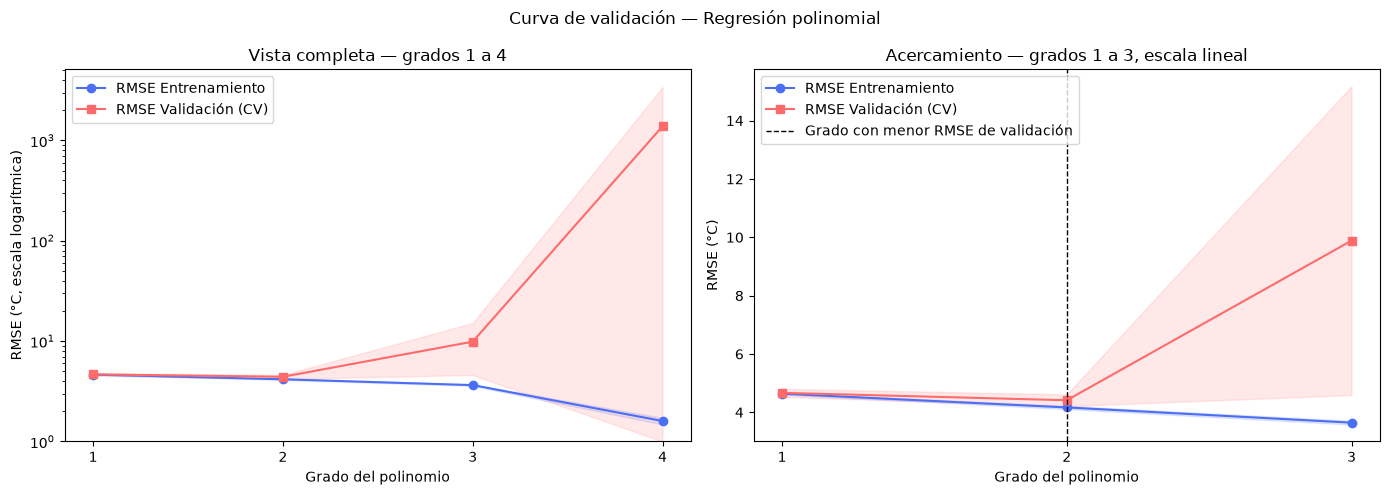

Si ambas curvas son altas y van juntas → subajuste (sesgo alto).
   Si la de entrenamiento sigue bajando y la de validación sube → sobreajuste (varianza alta).
   El grado óptimo es el que minimiza el RMSE de validación.


In [52]:
fig, (ax_global, ax_zoom) = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: los cuatro grados en escala logarítmica
ax_global.plot(grados_evaluados, train_rmse_mean, "o-", color="#4C6EF5", label="RMSE Entrenamiento")
ax_global.fill_between(grados_evaluados,
                       np.maximum(train_rmse_mean - train_rmse_std, 1),
                       train_rmse_mean + train_rmse_std, alpha=0.15, color="#4C6EF5")
ax_global.plot(grados_evaluados, validation_rmse_mean, "s-", color="#FF6B6B", label="RMSE Validación (CV)")
ax_global.fill_between(grados_evaluados,
                       np.maximum(validation_rmse_mean - validation_rmse_std, 1),
                       validation_rmse_mean + validation_rmse_std, alpha=0.15, color="#FF6B6B")
ax_global.set_yscale("log")
ax_global.set_ylim(bottom=1)
ax_global.set_xticks(grados_evaluados)
ax_global.set_xlabel("Grado del polinomio")
ax_global.set_ylabel("RMSE (°C, escala logarítmica)")
ax_global.set_title("Vista completa — grados 1 a 4")
ax_global.legend()

# Panel derecho: acercamiento a los grados 1 a 3 en escala lineal
zoom = [i for i, g in enumerate(grados_evaluados) if g <= 3]
grados_zoom = [grados_evaluados[i] for i in zoom]

ax_zoom.plot(grados_zoom, train_rmse_mean[zoom], "o-", color="#4C6EF5", label="RMSE Entrenamiento")
ax_zoom.fill_between(grados_zoom,
                     train_rmse_mean[zoom] - train_rmse_std[zoom],
                     train_rmse_mean[zoom] + train_rmse_std[zoom], alpha=0.15, color="#4C6EF5")
ax_zoom.plot(grados_zoom, validation_rmse_mean[zoom], "s-", color="#FF6B6B", label="RMSE Validación (CV)")
ax_zoom.fill_between(grados_zoom,
                     validation_rmse_mean[zoom] - validation_rmse_std[zoom],
                     validation_rmse_mean[zoom] + validation_rmse_std[zoom], alpha=0.15, color="#FF6B6B")
ax_zoom.axvline(grados_evaluados[int(np.argmin(validation_rmse_mean))], color="black",
                linestyle="--", lw=1, label="Grado con menor RMSE de validación")
ax_zoom.set_xticks(grados_zoom)
ax_zoom.set_xlabel("Grado del polinomio")
ax_zoom.set_ylabel("RMSE (°C)")
ax_zoom.set_title("Acercamiento — grados 1 a 3, escala lineal")
ax_zoom.legend()

fig.suptitle("Curva de validación — Regresión polinomial")
plt.tight_layout()
plt.show()

print("Si ambas curvas son altas y van juntas → subajuste (sesgo alto).")
print("   Si la de entrenamiento sigue bajando y la de validación sube → sobreajuste (varianza alta).")
print("   El grado óptimo es el que minimiza el RMSE de validación.")


### 6.2 Interpretación: sesgo-varianza y sobreajuste

*La curva reproduce el compromiso entre sesgo y varianza en sus tres tramos.*

***Grado 1: sesgo alto.*** *Las dos curvas están altas y prácticamente pegadas: el modelo comete casi el mismo error con los datos que vio y con los que no vio. Eso no es una virtud sino una señal de que el modelo es demasiado rígido para la estructura del problema; el error no viene de haber aprendido ruido sino de no poder representar la relación real. Es el extremo de sesgo alto y varianza baja.*

***Grado 2: el óptimo.*** *El error de entrenamiento baja y el de validación baja con él. Mientras las dos curvas se mueven en la misma dirección, la complejidad adicional está capturando estructura real y no ruido. Este es el punto que minimiza el RMSE de validación y coincide con el grado que seleccionó `GridSearchCV` en la sección 5.2.*

***Grados 3 y 4: varianza alta.*** *A partir del grado 3 las curvas se separan: la de entrenamiento sigue bajando mientras la de validación se dispara. Esa separación es la definición operativa del sobreajuste, y el punto de quiebre está entre el grado 2 y el 3. La banda de variabilidad crece junto con el error: en los grados altos la desviación estándar llega a ser del mismo orden que la media, es decir, el desempeño depende por completo de qué días caigan en cada partición. Un modelo así no solo predice mal, predice de forma impredecible.*

*El origen del problema es el conteo de parámetros. Sobre las once variables del Modelo B, la expansión genera 11 términos en grado 1, 78 en grado 2, 364 en grado 3 y 1365 en grado 4, frente a 1844 registros de entrenamiento. Cuando el número de parámetros se acerca al de observaciones, el modelo tiene grados de libertad suficientes para ajustar el ruido de la muestra, y en el límite puede interpolarla exactamente.*

*De aquí se desprende el argumento que continúa en las secciones 7 y 8: controlar la complejidad no tiene por qué hacerse solo eligiendo un grado bajo. La regularización permite conservar un grado alto y penalizar la magnitud de los coeficientes, que es una forma más fina de controlar la varianza que amputar términos por completo.*


## 7. Ridge y Lasso

*Se construyeron dos modelos de regresión lineal regularizada siguiendo la práctica P6: Ridge (penalización L2) y Lasso (penalización L1). Ambos usan el mismo preprocesamiento de la sección 4 pero sin la expansión polinomial, de modo que la única diferencia frente al modelo lineal de referencia sea la penalización sobre los coeficientes. El parámetro de penalización `alpha` se incluyó como hiperparámetro dentro de la búsqueda con `GridSearchCV`. La combinación de regularización con características polinomiales se trata aparte, en la sección 8.*


### 7.1 Modelo Ridge (regularización L2)

*Se definió `pipeline_ridge` como un pipeline completo que encadena las transformaciones de la sección 4 con el modelo `Ridge`. Como esta sección evalúa el efecto de la regularización por sí sola, se construyó un transformador numérico sin `PolynomialFeatures` (solo imputación y escalamiento): así el modelo tiene la misma complejidad que la regresión lineal de referencia y la única diferencia es la penalización L2, que reduce la magnitud de los coeficientes sin llevarlos exactamente a cero.*


In [53]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import KFold

numeric_transformer_regularizado = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
    ]
)

preprocessor_regularizado = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_regularizado, numeric_features_b),
    ]
)

pipeline_ridge = Pipeline(steps=[
    ("dropper", dropper),
    ("arreglar_escala_humedad", arreglar_escala_humedad_tr),
    ("crear_variables_dia", crear_variables_dia_tr),
    ("normalizar_mes", normalizar_mes_tr),
    ("normalizar_estacion", normalizar_estacion_tr),
    ("normalizar_sector_viento", normalizar_sector_viento_tr),
    ("corregir_validez", corregir_validez_tr),
    ("preprocesamiento", preprocessor_regularizado),
    ("modelo", Ridge())
])


*Se delimitó el espacio de búsqueda del hiperparámetro `alpha`. Se usó una escala logarítmica amplia porque `alpha` controla el peso de la penalización frente al error de ajuste y su valor apropiado depende de la escala de la variable objetivo: como aquí se predicen grados centígrados y no precios, los valores de la práctica quedaban fuera de rango (con `alpha = 100` Lasso lleva todos los coeficientes a cero y el modelo se reduce a predecir el promedio). La grilla incluye tanto los valores de la práctica como la escala logarítmica sugerida en sus ejercicios.*


In [54]:
param_grid_ridge = {
    "modelo__alpha": [0.001, 0.01, 0.1, 1, 10, 20, 30, 100, 300, 1000]
}


*Se definió un objeto `KFold` que genera las particiones para la validación cruzada sobre el conjunto de entrenamiento. Se configuró con k = 10 y `shuffle=True`: mezclar antes de partir es importante en este conjunto porque los registros están ordenados por fecha, y sin mezclar cada partición sería un bloque temporal contiguo (una estación del año completa), lo que hace que los resultados dependan del periodo que quede en validación. Se fijó `random_state` para que las particiones sean reproducibles.*


In [55]:
kfold = KFold(n_splits=10, shuffle=True, random_state = 1)


*Se creó el objeto `GridSearchCV` que busca el mejor valor de `alpha` mediante la validación cruzada definida.*


In [56]:
grid_ridge = GridSearchCV(estimator=pipeline_ridge, param_grid=param_grid_ridge,cv=kfold, n_jobs=-1)


In [57]:
%%time
grid_ridge.fit(X_train, y_train)


CPU times: user 144 ms, sys: 6 ms, total: 150 ms
Wall time: 346 ms


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...o', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'modelo__alpha': [0.001, 0.01, ...]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of info

*Se revisó cuál valor de `alpha` obtuvo el mejor desempeño en validación cruzada.*


In [58]:
print("Mejores hiperparámetros Ridge:", grid_ridge.best_params_)


Mejores hiperparámetros Ridge: {'modelo__alpha': 10}


*Se guardó el mejor pipeline entrenado encontrado por `GridSearchCV` y se calcularon sus predicciones sobre el conjunto de entrenamiento.*


In [59]:
best_ridge = grid_ridge.best_estimator_


In [60]:
y_pred_ridge_train  = best_ridge.predict(X_train)


In [61]:
rmse_ridge_train = np.sqrt(mean_squared_error(y_train, y_pred_ridge_train))
mae_ridge_train  = mean_absolute_error(y_train, y_pred_ridge_train)
r2_ridge_train   = r2_score(y_train, y_pred_ridge_train)

print(f"RMSE: {rmse_ridge_train:.3f}")
print(f"MAE: {mae_ridge_train:.3f}")
print(f"R²: {r2_ridge_train:.3f}")


RMSE: 4.644
MAE: 3.672
R²: 0.735


#### Validación del modelo

*Se calcularon los indicadores del modelo Ridge sobre el conjunto de prueba.*


In [62]:
y_pred_ridge_test = best_ridge.predict(X_test)

rmse_ridge_test = np.sqrt(mean_squared_error(y_test, y_pred_ridge_test))
mae_ridge_test  = mean_absolute_error(y_test, y_pred_ridge_test)
r2_ridge_test   = r2_score(y_test, y_pred_ridge_test)

print(f"RMSE: {rmse_ridge_test:.3f}")
print(f"MAE:  {mae_ridge_test:.3f}")
print(f"R²:   {r2_ridge_test:.3f}")


RMSE: 4.928
MAE:  3.731
R²:   0.697


#### Revisión de coeficientes

*Revisar los coeficientes en Ridge permite comprender el efecto de la regularización L2: penaliza la magnitud de los coeficientes, empujándolos hacia valores más pequeños sin llevarlos exactamente a cero.*


In [63]:
preproc_fitted_ridge = best_ridge.named_steps["preprocesamiento"]
feature_names_ridge = preproc_fitted_ridge.get_feature_names_out()
coefs_ridge = best_ridge.named_steps["modelo"].coef_

coef_ridge_df = pd.DataFrame({
    "Característica": feature_names_ridge,
    "coef_ridge": coefs_ridge
})
coef_ridge_df["Característica"] = coef_ridge_df["Característica"].str.split("__").str[-1]
coef_ridge_df["coef_ridge"] = coef_ridge_df["coef_ridge"].round(3)
coef_ridge_df_sorted = coef_ridge_df.sort_values(
    "coef_ridge", key=abs, ascending=False
)
coef_ridge_df_sorted


,Característica,coef_ridge
9,dia_cos,-5.768
8,dia_sin,-2.150
7,humedad_desv,1.836
4,humedad_media,-0.559
2,presion_max,0.391
3,presion_desv,-0.378
10,viento_este,-0.316
1,presion_min,-0.305
6,humedad_max,-0.278
5,humedad_min,-0.202


### 7.2 Modelo Lasso (regularización L1)

*Se definió el pipeline para `Lasso`, idéntico al de Ridge salvo por el modelo final. Se usó `max_iter=5000` como en la práctica*


In [64]:
pipeline_lasso = Pipeline(steps=[
    ("dropper", dropper),
    ("arreglar_escala_humedad", arreglar_escala_humedad_tr),
    ("crear_variables_dia", crear_variables_dia_tr),
    ("normalizar_mes", normalizar_mes_tr),
    ("normalizar_estacion", normalizar_estacion_tr),
    ("normalizar_sector_viento", normalizar_sector_viento_tr),
    ("corregir_validez", corregir_validez_tr),
    ("preprocesamiento", preprocessor_regularizado),
    ("modelo", Lasso(max_iter=5000))
])


*Al igual que con Ridge, se delimitó el espacio de búsqueda de `alpha` en `param_grid_lasso`, con la misma grilla para que la comparación entre ambos modelos sea equivalente.*


In [65]:
param_grid_lasso = {
    "modelo__alpha": [0.001, 0.01, 0.1, 1, 10, 20, 30, 100, 300, 1000]
}


In [66]:
grid_lasso = GridSearchCV(estimator=pipeline_lasso, param_grid=param_grid_lasso,cv=kfold, n_jobs=-1)


In [67]:
%%time
grid_lasso.fit(X_train, y_train)


CPU times: user 141 ms, sys: 6.09 ms, total: 148 ms
Wall time: 338 ms


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=5000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'modelo__alpha': [0.001, 0.01, ...]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of inform

In [68]:
print("Mejores hiperparámetros Lasso:", grid_lasso.best_params_)


Mejores hiperparámetros Lasso: {'modelo__alpha': 0.001}


In [69]:
best_lasso = grid_lasso.best_estimator_


In [70]:
y_pred_lasso_train  = best_lasso.predict(X_train)


In [71]:
rmse_lasso_train = np.sqrt(mean_squared_error(y_train, y_pred_lasso_train))
mae_lasso_train  = mean_absolute_error(y_train, y_pred_lasso_train)
r2_lasso_train   = r2_score(y_train, y_pred_lasso_train)

print(f"RMSE: {rmse_lasso_train:.3f}")
print(f"MAE: {mae_lasso_train:.3f}")
print(f"R²: {r2_lasso_train:.3f}")


RMSE: 4.644
MAE: 3.673
R²: 0.735


#### Validación del modelo

*Se calcularon los indicadores del modelo Lasso sobre el conjunto de prueba.*


In [72]:
y_pred_lasso_test = best_lasso.predict(X_test)

rmse_lasso_test = np.sqrt(mean_squared_error(y_test, y_pred_lasso_test))
mae_lasso_test  = mean_absolute_error(y_test, y_pred_lasso_test)
r2_lasso_test   = r2_score(y_test, y_pred_lasso_test)

print(f"RMSE: {rmse_lasso_test:.3f}")
print(f"MAE:  {mae_lasso_test:.3f}")
print(f"R²:   {r2_lasso_test:.3f}")


RMSE: 4.930
MAE:  3.735
R²:   0.697


#### Revisión de coeficientes

*A diferencia de Ridge, la penalización L1 de Lasso sí lleva coeficientes exactamente a cero, por lo que la tabla de coeficientes es además una selección automática de variables.*


In [73]:
preproc_fitted_lasso = best_lasso.named_steps["preprocesamiento"]
feature_names_lasso = preproc_fitted_lasso.get_feature_names_out()
coefs_lasso = best_lasso.named_steps["modelo"].coef_

coef_lasso_df = pd.DataFrame({
    "Característica": feature_names_lasso,
    "coef_lasso": coefs_lasso
})
coef_lasso_df["Característica"] = coef_lasso_df["Característica"].str.split("__").str[-1]
coef_lasso_df["coef_lasso"] = coef_lasso_df["coef_lasso"].round(3)
coef_lasso_df_sorted = coef_lasso_df.sort_values(
    "coef_lasso", key=abs, ascending=False
)
coef_lasso_df_sorted


,Característica,coef_lasso
9,dia_cos,-5.808
8,dia_sin,-2.159
7,humedad_desv,1.874
4,humedad_media,-0.552
2,presion_max,0.420
3,presion_desv,-0.381
1,presion_min,-0.329
10,viento_este,-0.320
6,humedad_max,-0.299
0,presion_media,0.169


### 7.3 Comparación: sin regularización vs. Ridge vs. Lasso

*Se resumieron en una tabla los resultados de los tres enfoques: el modelo sin regularización seleccionado en la sección 5, Ridge y Lasso. Se reportan las métricas en entrenamiento y en prueba, ya que la diferencia entre ambas es lo que permite valorar el efecto de la penalización sobre la generalización.*


In [74]:
y_pred_sinreg_train = mejor_modelo.predict(X_train)
y_pred_sinreg_test  = mejor_modelo.predict(X_test)

resultados_modelos = pd.DataFrame([
    {
        "Modelo": "Sin regularización (sección 5)",
        "RMSE_train": np.sqrt(mean_squared_error(y_train, y_pred_sinreg_train)),
        "MAE_train":  mean_absolute_error(y_train, y_pred_sinreg_train),
        "R2_train":   r2_score(y_train, y_pred_sinreg_train),
        "RMSE_test":  np.sqrt(mean_squared_error(y_test, y_pred_sinreg_test)),
        "MAE_test":   mean_absolute_error(y_test, y_pred_sinreg_test),
        "R2_test":    r2_score(y_test, y_pred_sinreg_test),
    },
    {
        "Modelo": "Ridge",
        "RMSE_train": rmse_ridge_train,
        "MAE_train":  mae_ridge_train,
        "R2_train":   r2_ridge_train,
        "RMSE_test":  rmse_ridge_test,
        "MAE_test":   mae_ridge_test,
        "R2_test":    r2_ridge_test,
    },
    {
        "Modelo": "Lasso",
        "RMSE_train": rmse_lasso_train,
        "MAE_train":  mae_lasso_train,
        "R2_train":   r2_lasso_train,
        "RMSE_test":  rmse_lasso_test,
        "MAE_test":   mae_lasso_test,
        "R2_test":    r2_lasso_test,
    }
])
resultados_modelos.style.format("{:.3f}", subset=pd.IndexSlice[:, resultados_modelos.columns != "Modelo"])


,Modelo,RMSE_train,MAE_train,R2_train,RMSE_test,MAE_test,R2_test
0,Sin regularización (sección 5),4.189,3.267,0.785,4.675,3.487,0.728
1,Ridge,4.644,3.672,0.735,4.928,3.731,0.697
2,Lasso,4.644,3.673,0.735,4.930,3.735,0.697


*Se compararon también las magnitudes de los coeficientes de los tres modelos, que es donde se ve de forma más directa el efecto de cada tipo de penalización.*


In [75]:
comparacion_coeficientes = pd.DataFrame([
    {
        "Modelo": "Ridge",
        "Coeficientes": len(coefs_ridge),
        "Coeficientes distintos de cero": int((coefs_ridge != 0).sum()),
        "|coef| máximo": np.abs(coefs_ridge).max(),
        "|coef| promedio": np.abs(coefs_ridge).mean(),
    },
    {
        "Modelo": "Lasso",
        "Coeficientes": len(coefs_lasso),
        "Coeficientes distintos de cero": int((coefs_lasso != 0).sum()),
        "|coef| máximo": np.abs(coefs_lasso).max(),
        "|coef| promedio": np.abs(coefs_lasso).mean(),
    },
])
display(comparacion_coeficientes)


,Modelo,Coeficientes,Coeficientes distintos de cero,|coef| máximo,|coef| promedio
0,Ridge,11,11,5.767686,1.123538
1,Lasso,11,11,5.808426,1.132595


*La penalización no reduce el error ni la magnitud de los coeficientes de forma apreciable.*




### 7.4 Variables llevadas a cero por Lasso

*Se identificaron las variables cuyo coeficiente Lasso llevó exactamente a cero, es decir, las que el modelo descartó por completo de la predicción.*


In [90]:
variables_en_cero = coef_lasso_df[coef_lasso_df["coef_lasso"] == 0]
variables_conservadas = coef_lasso_df[coef_lasso_df["coef_lasso"] != 0]

print(f"Variables llevadas a cero: {variables_en_cero.shape[0]} de {coef_lasso_df.shape[0]}")
print(f"Variables conservadas: {variables_conservadas.shape[0]}")




Variables llevadas a cero: 0 de 11
Variables conservadas: 11


*Con el `alpha` óptimo Lasso puede no descartar ninguna variable, lo cual es esperable: la selección de características ya se hizo de forma manual y justificada en el Laboratorio 1, y las once variables del Modelo B fueron elegidas precisamente por no ser redundantes. Para observar el mecanismo de selección L1 se recorrió el camino de regularización, aumentando `alpha` progresivamente y registrando qué variables van cayendo a cero y a qué costo en desempeño. El orden de eliminación indica cuáles aportan menos información única.*


In [77]:
camino_lasso = []

for a in [0.001, 0.01, 0.1, 1, 10, 20, 30]:
    lasso_a = Pipeline(steps=pipeline_lasso.steps[:-1] + [("modelo", Lasso(alpha=a, max_iter=5000))])
    lasso_a.fit(X_train, y_train)

    coefs_a = lasso_a.named_steps["modelo"].coef_
    nombres_a = [n.split("__")[-1] for n in lasso_a.named_steps["preprocesamiento"].get_feature_names_out()]
    en_cero_a = [n for n, v in zip(nombres_a, coefs_a) if v == 0]

    camino_lasso.append({
        "alpha": a,
        "Variables conservadas": int((coefs_a != 0).sum()),
        "R2_test": r2_score(y_test, lasso_a.predict(X_test)),
        "Variables en cero": ", ".join(en_cero_a) if en_cero_a else "(ninguna)",
    })

display(pd.DataFrame(camino_lasso))


,alpha,Variables conservadas,R2_test,Variables en cero
0,0.001,11,0.697006,(ninguna)
1,0.010,11,0.696579,(ninguna)
2,0.100,10,0.695430,presion_min
3,1.000,4,0.662121,"presion_media, presion_min, presion_max, presi..."
4,10.000,0,-0.016264,"presion_media, presion_min, presion_max, presi..."
5,20.000,0,-0.016264,"presion_media, presion_min, presion_max, presi..."
6,30.000,0,-0.016264,"presion_media, presion_min, presion_max, presi..."


## 8. Regresión polinomial regularizada

*Se combinó la generación de características polinomiales de la sección 5 con los modelos regularizados de la sección 7, en un único pipeline. La búsqueda con `GridSearchCV` exploró simultáneamente los tres hiperparámetros que pide el enunciado (grado del polinomio, parámetro de penalización y estrategia de escalamiento) y el desempeño se evaluó mediante validación cruzada con RMSE, MAE y R².*


### 8.1 Pipeline combinado (polinomial + regularización)

*Se construyeron dos pipelines combinados, uno con Ridge y otro con Lasso, idénticos salvo por el modelo final. Ambos parten de la misma preparación del Modelo B y encadenan imputación, escalamiento y expansión polinomial antes del modelo regularizado. El escalamiento debe ir antes de la expansión polinomial, porque de lo contrario los términos de grado superior quedarían en escalas muy distintas entre sí. Lasso se configuró con `max_iter=20000`, más que las iteraciones usadas en la sección 7, porque al aumentar el grado del polinomio crece el número de características y el algoritmo de descenso por coordenadas necesita más iteraciones para converger.*


In [78]:
numeric_transformer_polinomial_regularizado = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("polynomial", PolynomialFeatures(degree=2)),
    ]
)

preprocessor_polinomial_regularizado = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_polinomial_regularizado, numeric_features_b),
    ]
)

pipeline_polinomial_ridge = Pipeline(steps=[
    ("dropper", dropper),
    ("arreglar_escala_humedad", arreglar_escala_humedad_tr),
    ("crear_variables_dia", crear_variables_dia_tr),
    ("normalizar_mes", normalizar_mes_tr),
    ("normalizar_estacion", normalizar_estacion_tr),
    ("normalizar_sector_viento", normalizar_sector_viento_tr),
    ("corregir_validez", corregir_validez_tr),
    ("preprocesamiento", preprocessor_polinomial_regularizado),
    ("modelo", Ridge())
])

pipeline_polinomial_lasso = Pipeline(steps=[
    ("dropper", dropper),
    ("arreglar_escala_humedad", arreglar_escala_humedad_tr),
    ("crear_variables_dia", crear_variables_dia_tr),
    ("normalizar_mes", normalizar_mes_tr),
    ("normalizar_estacion", normalizar_estacion_tr),
    ("normalizar_sector_viento", normalizar_sector_viento_tr),
    ("corregir_validez", corregir_validez_tr),
    ("preprocesamiento", preprocessor_polinomial_regularizado),
    ("modelo", Lasso(max_iter=20000))
])


### 8.2 Búsqueda de hiperparámetros (grado, penalización y escalamiento)

*El espacio de búsqueda combina los tres hiperparámetros: el grado del polinomio (1, 2 y 3), la estrategia de escalamiento y el parámetro de penalización `alpha`. `StandardScaler`, `RobustScaler` y `MinMaxScaler` producen modelos distintos cuando hay penalización.*


In [79]:
param_grid_polinomial_regularizado = {
    "preprocesamiento__num__polynomial__degree": [1, 2, 3],
    "preprocesamiento__num__scaler": [StandardScaler(), RobustScaler(), MinMaxScaler()],
    "modelo__alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
}


*Se presentan 63 combinaciones. Para mantener el costo de cómputo razonable se usó una validación cruzada de 5 particiones en lugar de las 10 de la sección 7 (315 ajustes por modelo), conservando `shuffle=True` por la misma razón: los registros están ordenados por fecha.*

*Se evaluaron las tres métricas simultáneamente mediante un diccionario de `scoring`, y se indicó con `refit="rmse"` que el modelo final se seleccione por RMSE, la métrica principal del laboratorio. Esto permite reportar media y desviación estándar de RMSE, MAE y R² en validación cruzada, como pide el enunciado.*


In [80]:
kfold_busqueda = KFold(n_splits=5, shuffle=True, random_state=1)

metricas = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
}

grid_polinomial_ridge = GridSearchCV(
    estimator=pipeline_polinomial_ridge,
    param_grid=param_grid_polinomial_regularizado,
    cv=kfold_busqueda,
    scoring=metricas,
    refit="rmse",
    n_jobs=-1
)

grid_polinomial_lasso = GridSearchCV(
    estimator=pipeline_polinomial_lasso,
    param_grid=param_grid_polinomial_regularizado,
    cv=kfold_busqueda,
    scoring=metricas,
    refit="rmse",
    n_jobs=-1
)


In [81]:
%%time
grid_polinomial_ridge.fit(X_train, y_train)


CPU times: user 401 ms, sys: 13.6 ms, total: 414 ms
Wall time: 1.08 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...o', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'modelo__alpha': [0.001, 0.01, ...], 'preprocesamiento__num__polynomial__degree': [1, 2, ...], 'preprocesamiento__num__scaler': [StandardScaler(), RobustScaler(), ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'mae': 'neg_mean_absolute_error', 'r2': 'r2', 'rmse': 'neg_root_mean_squared_error'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'rmse'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validat

In [82]:
%%time
grid_polinomial_lasso.fit(X_train, y_train)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.343019e+02, tolerance: 1.184e+01
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.231463e+03, tolerance: 1.208e+01
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number o

CPU times: user 713 ms, sys: 31 ms, total: 744 ms
Wall time: 15.1 s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.718731e+03, tolerance: 1.216e+01
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.233295e+03, tolerance: 1.184e+01
  model = cd_fast.enet_coordinate_descent(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...iter=20000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'modelo__alpha': [0.001, 0.01, ...], 'preprocesamiento__num__polynomial__degree': [1, 2, ...], 'preprocesamiento__num__scaler': [StandardScaler(), RobustScaler(), ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'mae': 'neg_mean_absolute_error', 'r2': 'r2', 'rmse': 'neg_root_mean_squared_error'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'rmse'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validatio

*Se recuperaron las mejores combinaciones encontradas para cada familia de modelos.*


In [83]:
print("Mejor configuración polinomial + Ridge:", grid_polinomial_ridge.best_params_)
print("Mejor configuración polinomial + Lasso:", grid_polinomial_lasso.best_params_)

mejor_polinomial_ridge = grid_polinomial_ridge.best_estimator_
mejor_polinomial_lasso = grid_polinomial_lasso.best_estimator_


Mejor configuración polinomial + Ridge: {'modelo__alpha': 1, 'preprocesamiento__num__polynomial__degree': 3, 'preprocesamiento__num__scaler': MinMaxScaler()}
Mejor configuración polinomial + Lasso: {'modelo__alpha': 0.1, 'preprocesamiento__num__polynomial__degree': 2, 'preprocesamiento__num__scaler': StandardScaler()}


### 8.3 Métricas y análisis de sobreajuste

*Se reportaron las tres métricas obtenidas por validación cruzada para la mejor configuración de cada familia, con su media y su desviación estándar. La desviación estándar es tan relevante como la media: indica qué tan consistente es el desempeño entre particiones y es el criterio de estabilidad que se usará en la sección 9.*


In [84]:
def metricas_validacion_cruzada(grid, nombre):
    i = grid.best_index_
    resultados = grid.cv_results_
    return {
        "Modelo": nombre,
        "RMSE_cv": -resultados["mean_test_rmse"][i],
        "RMSE_cv_std": resultados["std_test_rmse"][i],
        "MAE_cv": -resultados["mean_test_mae"][i],
        "MAE_cv_std": resultados["std_test_mae"][i],
        "R2_cv": resultados["mean_test_r2"][i],
        "R2_cv_std": resultados["std_test_r2"][i],
    }

metricas_cv_polinomial = pd.DataFrame([
    metricas_validacion_cruzada(grid_polinomial_ridge, "Polinomial + Ridge"),
    metricas_validacion_cruzada(grid_polinomial_lasso, "Polinomial + Lasso"),
])

display(metricas_cv_polinomial.round(4))


,Modelo,RMSE_cv,RMSE_cv_std,MAE_cv,MAE_cv_std,R2_cv,R2_cv_std
0,Polinomial + Ridge,4.3382,0.2037,3.3902,0.0816,0.7673,0.0219
1,Polinomial + Lasso,4.3564,0.1959,3.3947,0.0883,0.7654,0.0209


*Se evaluaron también ambos modelos sobre el conjunto de prueba, con las mismas tres métricas.*


In [85]:
resultados_polinomial_regularizado = []

for nombre, modelo_final in [("Polinomial + Ridge", mejor_polinomial_ridge),
                             ("Polinomial + Lasso", mejor_polinomial_lasso)]:
    pred_train = modelo_final.predict(X_train)
    pred_test = modelo_final.predict(X_test)
    resultados_polinomial_regularizado.append({
        "Modelo": nombre,
        "RMSE_train": np.sqrt(mean_squared_error(y_train, pred_train)),
        "RMSE_test": np.sqrt(mean_squared_error(y_test, pred_test)),
        "MAE_test": mean_absolute_error(y_test, pred_test),
        "R2_train": r2_score(y_train, pred_train),
        "R2_test": r2_score(y_test, pred_test),
    })

display(pd.DataFrame(resultados_polinomial_regularizado).round(4))


,Modelo,RMSE_train,RMSE_test,MAE_test,R2_train,R2_test
0,Polinomial + Ridge,4.1834,4.5876,3.4243,0.7851,0.7377
1,Polinomial + Lasso,4.2744,4.6294,3.4569,0.7757,0.7329


## 9. Comparación y selección del mejor modelo

*Se compararon los modelos construidos en las secciones 5, 7 y 8 considerando tanto el valor promedio de la métrica principal como su estabilidad (desviación estándar en validación cruzada).*

### 9.1 Tabla comparativa de modelos

*Se construyó una tabla comparativa que cruza el grado del polinomio con el tipo de penalización, reuniendo los modelos de las secciones 5, 7 y 8. Para cada grado se recuperó de las búsquedas de la sección 8 la mejor configuración de Ridge y de Lasso, y se comparó contra el mismo grado sin regularizar.*

*Además del desempeño en prueba se reporta la media y la desviación estándar del RMSE en validación cruzada, calculadas sobre las mismas particiones (`kfold_busqueda`) para que las nueve configuraciones sean comparables entre sí. La desviación estándar es lo que permite valorar la estabilidad, no solo el nivel de error.*


In [86]:
from sklearn.base import clone


def mejor_configuracion_por_grado(grid, grado):
    resultados = pd.DataFrame(grid.cv_results_)
    del_grado = resultados[
        resultados["param_preprocesamiento__num__polynomial__degree"] == grado
    ]
    return del_grado.loc[del_grado["mean_test_rmse"].idxmax(), "params"]


def evaluar(nombre, grado, pipeline_base, parametros):
    modelo_evaluado = clone(pipeline_base)
    modelo_evaluado.set_params(**parametros)

    rmse_cv = -cross_val_score(
        modelo_evaluado, X_train, y_train,
        cv=kfold_busqueda, scoring="neg_root_mean_squared_error", n_jobs=-1
    )

    modelo_evaluado.fit(X_train, y_train)
    coeficientes = modelo_evaluado.named_steps["modelo"].coef_
    pred_train = modelo_evaluado.predict(X_train)
    pred_test = modelo_evaluado.predict(X_test)

    return {
        "Grado": grado,
        "Modelo": nombre,
        "Coeficientes != 0": int((coeficientes != 0).sum()),
        "RMSE_cv": rmse_cv.mean(),
        "RMSE_cv_std": rmse_cv.std(),
        "R2_train": r2_score(y_train, pred_train),
        "R2_test": r2_score(y_test, pred_test),
        "RMSE_test": np.sqrt(mean_squared_error(y_test, pred_test)),
    }


comparacion_modelos = []

for grado in [1, 2, 3]:
    comparacion_modelos.append(evaluar(
        "Sin regularización", grado, pipeline_regresion_polinomial,
        {"preprocesamiento__num__polynomial__degree": grado,
         "preprocesamiento__num__scaler": StandardScaler()}
    ))
    comparacion_modelos.append(evaluar(
        "Ridge", grado, pipeline_polinomial_ridge,
        mejor_configuracion_por_grado(grid_polinomial_ridge, grado)
    ))
    comparacion_modelos.append(evaluar(
        "Lasso", grado, pipeline_polinomial_lasso,
        mejor_configuracion_por_grado(grid_polinomial_lasso, grado)
    ))

tabla_comparativa = pd.DataFrame(comparacion_modelos)

columnas_texto = ["Grado", "Modelo", "Coeficientes != 0"]
tabla_comparativa.style.format("{:.3f}", subset=pd.IndexSlice[:, ~tabla_comparativa.columns.isin(columnas_texto)])


,Grado,Modelo,Coeficientes != 0,RMSE_cv,RMSE_cv_std,R2_train,R2_test,RMSE_test
0,1,Sin regularización,11,4.663,0.217,0.735,0.697,4.930
1,1,Ridge,11,4.662,0.215,0.735,0.697,4.932
2,1,Lasso,10,4.662,0.216,0.735,0.697,4.934
3,2,Sin regularización,78,4.411,0.209,0.785,0.728,4.675
4,2,Ridge,77,4.360,0.210,0.781,0.733,4.625
5,2,Lasso,29,4.356,0.196,0.776,0.733,4.629
6,3,Sin regularización,364,15.366,8.744,0.826,0.473,6.501
7,3,Ridge,363,4.338,0.204,0.785,0.738,4.588
8,3,Lasso,72,4.367,0.253,0.790,0.743,4.544


### 9.2 Selección y justificación del modelo final

*La selección se hizo sobre el RMSE en **validación cruzada**, no sobre el conjunto de test. Elegir por test convertiría la prueba en parte del entrenamiento: el modelo quedaría escogido por los mismos datos con los que después se afirma que generaliza, y la métrica reportada dejaría de ser una estimación honesta.*

**Modelo seleccionado: regresión polinomial de grado 3 con regularización Ridge**, con `MinMaxScaler` y `alpha = 1`.

*Obtuvo el menor RMSE promedio en validación cruzada (4.338 °C) y una desviación estándar de 0.204, prácticamente empatada con la más baja de toda la tabla (0.196 del polinomial de grado 2 con Lasso). Es decir, gana en promedio sin pagar nada en estabilidad, que son los dos criterios que pide el enunciado.*

*Las alternativas consideradas y por qué no se eligieron:*

- ***Polinomial de grado 2 con Lasso*** *(4.356 ± 0.196). Es el más estable por un margen mínimo y con diferencia el más simple: 29 coeficientes distintos de cero frente a los 363 del seleccionado. Si el criterio principal fuera la interpretabilidad, esta sería la elección, y la diferencia de desempeño es de dos centésimas de grado. Se comenta de nuevo en la sección 11.2.3.*
- ***Polinomial de grado 3 con Lasso*** *(4.367 ± 0.253). Es el que mejor resultado obtiene en test (RMSE 4.544 y R² 0.743), pero su promedio en validación cruzada es el peor de los tres y su desviación estándar la más alta. Seleccionarlo equivaldría a elegir por test, que es justamente lo que el criterio evita.*

*El contraste que justifica la forma del modelo final está en la fila del grado 3 sin regularizar: 15.366 ± 8.744 de RMSE en validación cruzada, con una desviación de casi el 60% de su propia media. El mismo grado, con penalización, baja a 4.338 ± 0.204. La complejidad alta no es utilizable por sí sola; lo que la vuelve utilizable es la regularización.*


## 10. Intervalos de confianza (bootstrapping)

*Se estimaron intervalos de confianza al 95% para las métricas de desempeño del modelo seleccionado, mediante bootstrapping sobre el conjunto de test. Reportar un único valor de RMSE, MAE o R² oculta que esas cifras se calcularon sobre una muestra concreta de días: con otros días el resultado habría sido distinto. El intervalo de confianza cuantifica ese margen y permite hablar de la confiabilidad del modelo, no solo de su precisión puntual.*


### 10.1 Procedimiento de bootstrapping (al menos 500 remuestreos)

*El bootstrapping consiste en generar muchas muestras a partir del conjunto de test mediante muestreo con reemplazo, calcular la métrica en cada una y construir con esos valores una distribución empírica. A diferencia de la validación cruzada, que divide los datos en particiones fijas, el bootstrapping simula muchas versiones posibles del conjunto de prueba a partir del que se tiene.*

*Se usaron 1000 remuestreos, el mismo número de las prácticas P5 y P6 y el doble del mínimo que exige el enunciado. En cada iteración se genera una muestra del mismo tamaño que el test original, se predice con el modelo ya entrenado y se calculan las tres métricas. El modelo no se reentrena: lo que se está midiendo es la variabilidad de su desempeño, no la de su entrenamiento.*


*Se fijó el generador aleatorio con `np.random.RandomState` para que el procedimiento sea reproducible. Pasar un generador en lugar de un número fijo es lo que permite que cada iteración obtenga una muestra distinta y que, aun así, la secuencia completa se repita igual en cada ejecución del notebook.*


In [87]:
modelo_seleccionado = mejor_polinomial_ridge

n_iterations = 1000
generador = np.random.RandomState(random_state)

stats_rmse = []
stats_mae = []
stats_r2 = []

for i in range(n_iterations):
    # Generar muestra con reemplazo
    X_resample, y_resample = resample(
        X_test, y_test, replace=True, n_samples=len(X_test), random_state=generador
    )

    pred = modelo_seleccionado.predict(X_resample)

    stats_rmse.append(np.sqrt(mean_squared_error(y_resample, pred)))
    stats_mae.append(mean_absolute_error(y_resample, pred))
    stats_r2.append(r2_score(y_resample, pred))

print("Remuestreos realizados:", len(stats_rmse))


Remuestreos realizados: 1000


*Con la distribución de cada métrica se calcularon los percentiles 2.5 y 97.5, que delimitan el intervalo que contiene el 95% central de los valores observados.*


In [88]:
# Calcular percentiles para el intervalo de confianza al 95%
alpha = 0.95
p_lower = ((1.0 - alpha) / 2.0) * 100
p_upper = (alpha + (1.0 - alpha) / 2.0) * 100

intervalos_confianza = []

for nombre, valores in [("RMSE", stats_rmse), ("MAE", stats_mae), ("R²", stats_r2)]:
    lower = np.percentile(valores, p_lower)
    upper = np.percentile(valores, p_upper)
    intervalos_confianza.append({
        "Métrica": nombre,
        "Media": np.mean(valores),
        "Límite inferior (2.5%)": lower,
        "Límite superior (97.5%)": upper,
        "Ancho del intervalo": upper - lower,
        "Ancho relativo (%)": 100 * (upper - lower) / abs(np.mean(valores)),
    })

intervalos_confianza = pd.DataFrame(intervalos_confianza)

intervalos_confianza.style.format("{:.4f}", subset=pd.IndexSlice[:, intervalos_confianza.columns != "Métrica"])


,Métrica,Media,Límite inferior (2.5%),Límite superior (97.5%),Ancho del intervalo,Ancho relativo (%)
0,RMSE,4.5787,4.0944,5.1669,1.0726,23.4255
1,MAE,3.4224,3.1735,3.6730,0.4995,14.5957
2,R²,0.7373,0.6721,0.7883,0.1162,15.7653


### 10.2 Distribución de errores y discusión de estabilidad

*Se graficó la distribución empírica de cada métrica. Las líneas rojas marcan los límites del intervalo de confianza al 95% y la verde la media de la distribución.*


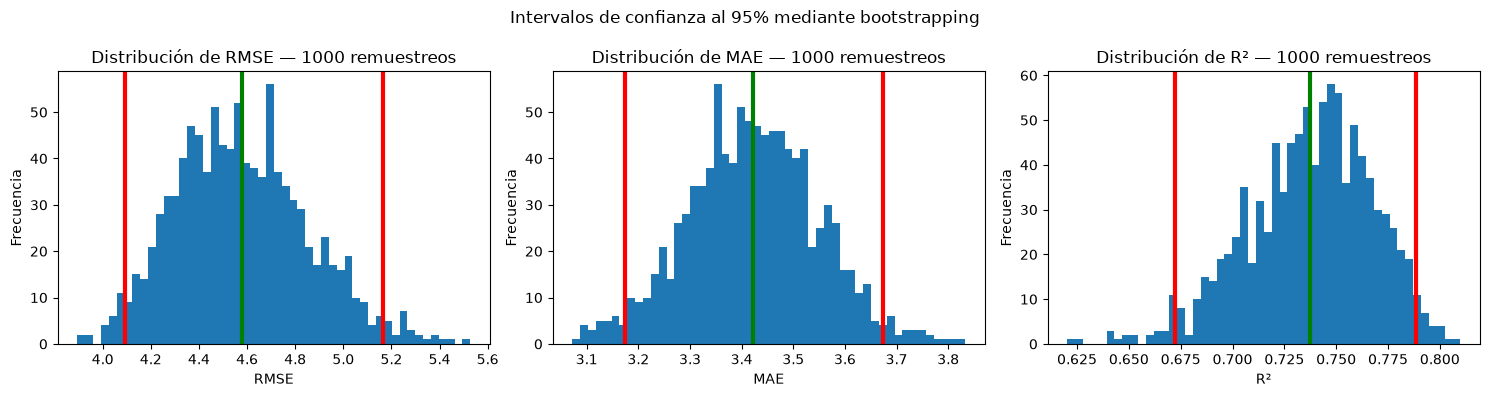

In [89]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (nombre, valores) in zip(axes, [("RMSE", stats_rmse), ("MAE", stats_mae), ("R²", stats_r2)]):
    lower = np.percentile(valores, p_lower)
    upper = np.percentile(valores, p_upper)

    ax.hist(valores, bins=50)
    ax.axvline(lower, color="red", linewidth=3)
    ax.axvline(np.mean(valores), color="green", linewidth=3)
    ax.axvline(upper, color="red", linewidth=3)
    ax.set_xlabel(nombre)
    ax.set_ylabel("Frecuencia")
    ax.set_title(f"Distribución de {nombre} — 1000 remuestreos")

fig.suptitle("Intervalos de confianza al 95% mediante bootstrapping")
plt.tight_layout()
plt.show()


*Las tres distribuciones son unimodales y aproximadamente simétricas alrededor de su media, sin colas largas ni valores extremos aislados. Esa forma ya es en sí un indicio de estabilidad: el desempeño del modelo no depende de un puñado de días particulares del conjunto de prueba, porque si así fuera, las muestras que los incluyen o los excluyen producirían dos grupos separados de valores.*

***Ancho de los intervalos.*** *El RMSE se mueve en una franja de aproximadamente un grado centígrado alrededor de su valor central, y el R² en algo más de una décima. Son intervalos estrechos frente a la magnitud de lo que se predice: la temperatura máxima del día siguiente tiene una desviación estándar cercana a 9 °C en este conjunto, de modo que el modelo reduce la incertidumbre a algo menos de la mitad, y esa reducción se sostiene de forma consistente en todas las remuestras.*

***Diferencia entre métricas.*** *En términos relativos el MAE es la métrica más estable y el RMSE la más variable. La razón es su definición: el RMSE eleva los errores al cuadrado, así que un solo día mal predicho pesa mucho más que en el MAE, y el resultado depende más de cuántos de esos días extremos caigan en cada remuestra. Es la misma sensibilidad a los valores atípicos que se observó en la sección 5 con el modelo sin regularizar.*

***Implicaciones para el uso del modelo.*** *Un intervalo estrecho significa que el desempeño reportado es confiable como estimación de lo que ocurriría con días nuevos, y no un resultado afortunado de la partición elegida. En términos de la aplicación, permite comunicar la predicción con un margen honesto: no "la temperatura máxima de mañana será X", sino "será X con un error típico de alrededor de Y grados". Para decisiones como la prevención de riesgo de incendio, esa franja es tan relevante como el valor central, porque determina con cuánto margen de seguridad debe tomarse una alerta.*


## 11. Análisis de resultados

*Se respondieron las preguntas de análisis con evidencia obtenida del proceso de modelado, sin inventar resultados.*

### 11.1 Análisis cuantitativo

#### 11.1.1 ¿Cuál modelo obtuvo el mejor desempeño en el conjunto de test?

*El mejor desempeño en test lo obtuvo la **regresión polinomial de grado 3 con Lasso**: RMSE de 4.544 °C y R² de 0.743, usando 72 de sus 364 coeficientes. El modelo seleccionado en la sección 9.2 (grado 3 con Ridge) queda inmediatamente detrás, con RMSE de 4.588 y R² de 0.738.*


#### 11.1.2 ¿Coincide el mejor desempeño en test con el mejor promedio en validación cruzada? Si no coincide, ¿cuál puede ser la explicación?

*No coincide: en validación cruzada el mejor promedio es el de Ridge (RMSE de 4.338 frente a 4.367 de Lasso), pero en test gana Lasso. La explicación es que el test son 615 días concretos y las diferencias entre ambos son de centésimas de grado, muy por debajo del margen de ±0.5 °C que arrojó el bootstrapping de la sección 10. Con modelos prácticamente empatados, el orden depende de qué días cayeron en la partición de prueba.*


#### 11.1.3 ¿El modelo con mejor métrica promedio es necesariamente el más adecuado? Justifica considerando también la desviación estándar del desempeño.

*No. El polinomio de grado 3 sin regularizar ilustra el punto: su RMSE promedio en validación cruzada es 15.366, pero con una desviación estándar de 8.744, es decir, más de la mitad de su propia media, lo que significa que su desempeño depende por completo de la partición. Entre los candidatos reales, el grado 2 con Lasso tiene la desviación más baja (0.196) con una media casi idéntica a la del ganador, y por eso se consideró como alternativa en la sección 9.2.*


#### 11.1.4 Con base en las curvas de validación, ¿cómo cambia el error a medida que aumenta la complejidad? ¿En qué punto se evidencia sobreajuste?

*El error de entrenamiento baja de forma monótona con la complejidad (4.640, 4.168, 3.647 y 1.321 de RMSE para los grados 1 a 4), mientras que el de validación baja solo hasta el grado 2 (4.415) y después se dispara a 9.885 y 7 827.909. El sobreajuste se evidencia a partir del grado 3, que es donde las dos curvas dejan de moverse en la misma dirección y empiezan a separarse.*


#### 11.1.5 ¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?

*Sobre el modelo de once variables de la sección 7 el efecto es nulo: la búsqueda eligió el `alpha` más pequeño de la grilla (0.001 en Lasso) y ninguna variable quedó en cero, porque con once parámetros para 1844 registros no hay varianza que controlar. Con la expansión polinomial el efecto es decisivo: el grado 3 pasa de una desviación estándar de 8.744 en validación cruzada a 0.204 al aplicar Ridge, y Lasso reduce el modelo de 364 coeficientes a 72 sin perder desempeño.*


#### 11.1.6 ¿Los intervalos de confianza obtenidos mediante bootstrapping sugieren estabilidad o alta variabilidad en el desempeño? ¿Qué implicaciones tiene esto?

*Sugieren estabilidad. Los intervalos al 95% son [4.094, 5.167] para el RMSE, [3.174, 3.673] para el MAE y [0.672, 0.788] para el R², con anchos de entre el 15% y el 23% de su media y distribuciones unimodales y simétricas. Frente a una variable objetivo cuya desviación estándar ronda los 9 °C, un margen de un grado indica que el desempeño reportado es confiable y no producto de una partición afortunada.*


### 11.2 Análisis cualitativo

#### 11.2.1 ¿Qué variables fueron seleccionadas como más relevantes por el modelo Lasso?

*El par `dia_cos` (−5.808) y `dia_sin` (−2.159) domina por completo, seguido a distancia por `humedad_desv` (+1.874) y `humedad_media` (−0.552). Con su `alpha` óptimo Lasso no descarta ninguna de las once variables, porque la selección ya se había hecho manualmente en el Laboratorio 1; al forzar la penalización hasta `alpha = 1`, las únicas que sobreviven son `humedad_min`, `humedad_desv`, `dia_sin` y `dia_cos`.*


#### 11.2.2 ¿Qué interpretación práctica tienen los coeficientes del modelo final en el contexto de la estimación de temperatura máxima?

*Como las variables están estandarizadas, cada coeficiente indica cuántos grados cambia la predicción por una desviación estándar de esa variable. El par `dia_sin` y `dia_cos` representa la posición en el ciclo anual y concentra el efecto de la estación; `humedad_media` es negativo, es decir, más humedad implica menos temperatura, y `humedad_desv` es positivo, consistente con días despejados de gran oscilación diurna. Esta lectura corresponde al modelo lineal de la sección 7: en el modelo final los coeficientes actúan sobre términos polinomiales cruzados y no admiten interpretación directa.*


#### 11.2.3 ¿Existen diferencias relevantes entre el modelo más preciso y el más interpretable?

*Sí, pero la diferencia de desempeño es mínima. El más preciso es el polinomial de grado 3, con R² de entre 0.738 y 0.743 pero entre 72 y 363 coeficientes sobre términos cruzados; el más interpretable es el modelo lineal de once variables de la sección 7, con R² de 0.697 y coeficientes que se leen directamente. En medio está el grado 2 con Lasso: 29 coeficientes y R² de 0.733, que sacrifica una centésima de R² a cambio de un modelo diez veces más pequeño.*


#### 11.2.4 ¿Qué decisiones estratégicas podría tomar AlpesPlanck a partir de los resultados obtenidos?

*Puede usar el modelo como sistema de alerta temprana comunicando siempre la predicción con su margen (un error típico cercano a 4.6 °C) en lugar de un valor puntual. Conviene priorizar la calidad y continuidad de la captura de humedad y presión, que son las variables que sostienen la predicción junto con la estacionalidad, y atender los problemas de consistencia detectados en la sección 3. Como la estación de Jena es un único punto de medición, ampliar la red permitiría extender el modelo a otras zonas.*


#### 11.2.5 ¿Mayor precisión implica necesariamente mayor valor para la organización? ¿Un modelo más complejo necesariamente genera mayor valor empresarial? Discute considerando interpretabilidad, estabilidad y costo de implementación.

*No. Pasar del modelo lineal al polinomial de grado 3 mejora el RMSE en test en 0.35 °C, pero lleva el modelo de 11 a 363 coeficientes sobre términos cruzados: deja de poder explicarse a un tomador de decisiones y se vuelve más costoso de mantener y auditar. El caso del grado 3 sin regularizar lo muestra en su extremo: más complejidad produjo el peor modelo del laboratorio, con R² negativo respecto a predecir el promedio en varias particiones.*


### 11.3 Reflexión conceptual

#### 11.3.1 ¿Qué relación observas entre complejidad del modelo, capacidad de generalización y estabilidad del desempeño?

*La generalización mejora con la complejidad solo hasta cierto punto y después se degrada, mientras que la estabilidad se deteriora antes y más rápido. En la tabla de la sección 9.1 la desviación estándar en validación cruzada se mantiene cerca de 0.2 en los grados 1 y 2 y salta a 8.744 en el grado 3 sin regularizar. Un modelo complejo pero penalizado recupera ambas cosas: el mismo grado 3 con Ridge vuelve a 0.204.*


#### 11.3.2 ¿Qué fuentes de sesgo podrían estar presentes en los datos o en el proceso de modelado?

*Los datos provienen de una sola estación meteorológica y de siete años (2009–2015), de modo que el modelo aprende el clima de Jena y no generaliza a otras zonas ni captura tendencias de largo plazo. A esto se suman decisiones del proceso que introducen sesgo: la imputación por la media achata la variabilidad de las variables incompletas, la eliminación de los registros sin variable objetivo asume que faltan de forma aleatoria, y las variables categóricas se descartaron por sus problemas de consistencia, junto con `anio`, cuya exclusión se justificó en el Laboratorio 1.*


#### 11.3.3 Si el tamaño de muestra fuera mayor, ¿esperarías cambios en la estabilidad de los modelos? Explique la respuesta.

*Sí, esperaría mayor estabilidad. El problema de los modelos de grado alto es la relación entre parámetros y registros: 364 coeficientes para 1844 datos de entrenamiento en el grado 3, y 1365 en el grado 4. Con más registros esa proporción mejora, las bandas de la curva de validación se estrecharían y el punto en que aparece el sobreajuste se desplazaría hacia grados más altos.*


## 12. Uso de herramientas de IA generativa

*Se declaró y analizó críticamente el uso de herramientas de IA generativa.*

### 12.1 Declaración del uso (herramienta y tipo de uso)

**Herramienta utilizada:** *Claude (Anthropic).*

**Tipos de uso:**

- ***Generación de la estructura del notebook.*** *A partir del enunciado del laboratorio se generó el esqueleto de secciones y subsecciones que organiza este documento, para completarlo con el desarrollo propio.*
- ***Explicación teórica.*** *Consultas conceptuales sobre herramientas del curso: qué recibe y qué devuelve `validation_curve`, cómo se lee su gráfica, qué relación tiene la curva de validación con la validación cruzada, si k-fold y validación cruzada son lo mismo, en qué consiste el bootstrapping y cómo interpretar un R² igual a 1 en el conjunto de entrenamiento.*

*El uso se concentró entonces en dos frentes: organizar el documento y aclarar conceptos antes de aplicarlos. La sección 6 es la que más se apoyó en la segunda consulta, ya que la curva de validación no aparece resuelta en ninguna práctica del curso y hubo que entender la función antes de escribirla; la explicación de cómo se construyó está en la nota metodológica de esa sección.*


### 12.2 Prompts utilizados

*Se registraron los prompts principales utilizados durante el trabajo, en orden cronológico:*

**Estructura del notebook**

- *"Basado en este md construye los apartados que debería tener para yo llenarlos; adicionalmente, en la parte de IA ve adicionando este prompt"* (adjuntando el enunciado del Laboratorio 2).


**Preparación de los datos**

- *"Tráete las decisiones adicionales que hicimos en el Modelo B del Laboratorio 1."* Con esto se recuperó la creación de `dia_sin` y `dia_cos` a partir del día del año mediante seno y coseno, ya declarada y justificada en el Laboratorio 1.

**Consultas conceptuales**

- *"Explícame qué hace la función `validation_curve` de scikit-learn: qué recibe, qué devuelve y cómo se lee la gráfica que sale de ahí."* A partir de esta consulta se construyó la sección 6, que no está resuelta en ninguna práctica del curso.
- *"¿Qué relación tiene la curva de validación con la validación cruzada?"* y *"¿k-fold y validación cruzada son lo mismo?"*
- *"Explícame de manera simple qué es bootstrapping."*
- *"¿Qué significa que ese R² me dé 1?"*




### 12.3 Análisis crítico del resultado (responder al menos dos de las siguientes preguntas)

***¿Qué partes del contenido generado fueron correctas y útiles?***

*La estructura de secciones generada a partir del enunciado fue útil como punto de partida: recoge las siete actividades y las preguntas de análisis en el orden en que las pide el laboratorio, de modo que ninguna quedó sin desarrollar. Es, sin embargo, un índice vacío; todo el contenido técnico y las decisiones son propios.*

*Las explicaciones conceptuales también fueron correctas y se verificaron contra el material del curso y la documentación de scikit-learn antes de aplicarlas. La más útil fue la de `validation_curve`, porque permitió escribir la sección 6 sin tener una práctica de referencia: entender que la función devuelve dos matrices (una por cada partición de la validación cruzada, para entrenamiento y para validación) es lo que llevó a calcular la media y la desviación estándar por grado y a graficar la banda de variabilidad que pide el enunciado.*

***¿Qué conceptos del curso permitieron evaluar o mejorar la respuesta generada?***

*La distinción entre validación cruzada y bootstrapping fue la que permitió verificar que cada técnica se estuviera usando donde corresponde. La validación cruzada reentrena el modelo sobre distintas particiones y mide la estabilidad del modelo; el bootstrapping mantiene el modelo entrenado y remuestrea el conjunto de test, de modo que mide la precisión de la métrica reportada. Por eso la selección del modelo en la sección 9.2 se hizo con validación cruzada y los intervalos de confianza de la sección 10 con bootstrapping, y no al revés.*

*El compromiso entre sesgo y varianza fue el criterio para interpretar el R² de 1.00 que arroja el modelo polinomial de grado 3 sin regularizar sobre el conjunto de entrenamiento. Sin ese concepto, ese valor parecería el mejor resultado del laboratorio; leído correctamente es el peor, y así lo confirma su R² de 0.473 en test. La explicación consultada aportó la definición, pero el diagnóstico salió de contrastar ese número con el conteo de parámetros del modelo (364 coeficientes para 1844 registros de entrenamiento) y con la curva de validación de la sección 6.*


### 12.4 Aportes propios de los estudiantes

***¿Qué fue desarrollado, modificado o decidido por los estudiantes?*** *La preparación completa sobre la que se construye el laboratorio proviene del Modelo B del Laboratorio 1: la selección de las once variables con su justificación, la corrección de escala de las variables de humedad y la codificación cíclica del día del año en `dia_sin` y `dia_cos`. Esta última es la decisión de mayor impacto de los dos laboratorios, porque sin ella la estacionalidad, el factor dominante de la temperatura, no puede entrar a un modelo lineal: en su forma cruda, el día 365 y el día 1 aparecen separados por 364 unidades siendo consecutivos en el calendario. También fue decisión propia el criterio de selección del modelo final: elegir por validación cruzada y no por test, y valorar la desviación estándar además del promedio, lo que llevó a descartar el modelo con mejor resultado en test.*

***¿Qué ajustes se realizaron sobre el código o la explicación original?*** *Los rangos de los hiperparámetros se ajustaron a la escala de este problema: los valores de `alpha` de las prácticas están calibrados para precios de vivienda y en grados centígrados dejaban a Lasso con todos los coeficientes en cero, por lo que se reemplazaron por una escala logarítmica amplia. En la sección 6 se cambió la escala del gráfico y se dividió en dos paneles, porque el error del grado 4 es tres órdenes de magnitud mayor que el del grado 2 y ocultaba el punto óptimo.*

***¿Qué aprendizajes se obtuvieron del proceso?*** *Que la complejidad no es buena ni mala por sí misma, sino según si está controlada: el mismo polinomio de grado 3 es el peor modelo del laboratorio sin regularización (R² de 0.473 en test) y el mejor con ella (0.738). La expansión de grado 3 sobre once variables genera 364 términos para 1844 registros de entrenamiento, y la penalización es lo que impide que el modelo use esa libertad para ajustar ruido.*


## 13. Referencias

**Fuente de datos**

- *Universidad de los Andes, curso ISIS-2611 Aprendizaje de Máquina. Conjunto de datos del caso AlpesPlanck: `Datos Lab 1.csv`, `Datos Test Lab 1.csv` y `Diccionario de datos.xlsx`. Registros meteorológicos de la estación de Jena, Alemania (2009–2015).*
- *Valbuena, L. y Goyeneche, J. (2026). Laboratorio 1: Exploración, preparación y regresión lineal. Curso ISIS-2611. De ahí provienen la preparación de datos y el Modelo B empleados en este laboratorio.*

**Material del curso**

- *Práctica P4: Regresión lineal (curva de aprendizaje con `learning_curve`).*
- *Práctica P5: Regresión polinomial y búsqueda de hiperparámetros.*
- *Práctica P6: Regresión regularizada (Ridge y Lasso) e intervalos de confianza por bootstrapping.*

**Documentación técnica**

- *Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research, 12, 2825–2830.*
- *Documentación de scikit-learn: `Pipeline`, `ColumnTransformer`, `PolynomialFeatures`, `GridSearchCV`, `validation_curve`, `Ridge` y `Lasso`. https://scikit-learn.org/stable/*

**Fuentes citadas en el análisis**

- *Deutscher Wetterdienst (2015). Récord nacional de temperatura de Alemania (40.3 °C), usado como cota para descartar registros físicamente imposibles.*
- *Copernicus Climate Change Service (C3S/ECMWF). European State of the Climate, sobre la tasa de calentamiento en Europa, citada en el Laboratorio 1 al descartar la variable `anio`.*
- *Ashford et al. (2026) y Holmberg et al. (2023), referenciados en el Laboratorio 1 para justificar la selección de las variables de humedad y de la componente zonal del viento.*

**Herramientas**

- *Claude (Anthropic), en los usos declarados en la sección 12.*
